In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import metapredict
import protfasta
import glob

Do patient variants affect disorder predictions?


# 1. Running metapredict on full ADs vs ADs with variants

In [2]:
known_ADs = pd.read_csv("../output/known_ADs_considering_isoforms_and_canonical.csv")
known_ADs

,Gene,Start,End,uniprotID,Matching Isoforms,Canonical Transcript ID,orig_uniprotID,Reference,TileType,ProteinRegionSeq,Notes
0,ABRAXAS1,121,200,Q6UWZ7,[['Q6UWZ7']],ENST00000321945,Q6UWZ7,DelRosso et al.,CR,LQEHFSNQDLVFLLLTPSIITESCSTHRLEHSLYKPQKGLFHRVPL...,NaN
1,AEBP1,1088,1158,Q8IUX7,[['Q8IUX7']],NaN,Q8IUX7,Staller Activity Data,TF,EVVTEFGTEVEPEFGTKVEPEFETQLEPEFETQLEPEFEEEEEEEK...,NaN
2,AHCTF1,1445,1698,Q8WYP5,"[['Q8WYP5'], ['Q8WYP5']]",nan / nan,Q8WYP5 / Q8WYP5,"PMID: 11952839, Soto / transcriptionalactivity...",TF,IRANDNKSMADVLGDGGNSSLTISEGPIVSERRLNQEVALNLKEDH...,NaN
3,AHR,118,126,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL",TF,LLQALNGFV,NaN
4,AHR,266,268,P35869,[['P35869']],NaN,P35869,"transcriptionalactivity_regions.txt, GSL",TF,FAI,NaN
...,...,...,...,...,...,...,...,...,...,...,...
739,ZSCAN20,262,341,P17040,"[['P17040', 'P17040-3']]",ENST00000361328,P17040,DelRosso et al.,TF,PSNTSEKEQGPEFWGLSLINSGKRSTADYSLDNEPAQALTWRDSRA...,NaN
740,ZXDA,572,699,P98168,"[['P98168'], ['P98168']]",nan / nan,P98168 / P98168 / P98168,"PMID: 17493635, Soto / R4TA_regions.txt / acti...",TF,QDLLAQLEAANSLTPSSELTSQRQNDLSDAEIVSLFSDVPDSTSAA...,NaN
741,ZXDB,576,703,P98169,[['P98169']],NaN,P98169 / P98169,"R4TA_regions.txt / activation_regions.txt, GSL",TF,QDLLAQLEAANSLTPSSELTSQRQNDLSDAEIVSLFSDVPDSTSAA...,NaN
742,ZXDC,579,688,Q2QGD7,"[['Q2QGD7', 'Q2QGD7-2'], ['Q2QGD7', 'Q2QGD7-2']]",nan / nan,Q2QGD7 / Q2QGD7 / Q2QGD7,"PMID: 16600381, Soto / R4TA_regions.txt / acti...",TF,DSPLVLGTAATVLQQGSFSVDDVQTVSAGALGCLVALPMKNLSDDP...,NaN


In [3]:
# For each SFARI AD: Running metapredict on all pt variants and wt seq

all_AD_dfs = []

for path in glob.glob("../soto_analysis/outputs/AD_variant_fasta_saved/*"):
    AD_dict = protfasta.read_fasta(path)
    
    name = path.split("/")[-1]
    uniprot_ID = name.split("_")[1]
    start = int(name.split("_")[-1].split("-")[0])
    end = int(name.split("_")[-1].split("-")[1])
    
    wt_seq = known_ADs[(known_ADs["uniprotID"].str.contains(uniprot_ID)) & (known_ADs["Start"] == start) & (known_ADs["End"] == end)]["ProteinRegionSeq"].iloc[0]
    
    AD_df = pd.DataFrame({"key" : AD_dict.keys(), "seq" : AD_dict.values()})
    AD_df["name"] = name
    AD_df["wt_disorder"] = metapredict.percent_disorder(wt_seq)
    
    AD_df["disorder"] = AD_df["seq"].apply(lambda s: metapredict.percent_disorder(s))
    all_AD_dfs.append(AD_df)

In [4]:
# Saving in one large dataframe

all_AD_df = pd.concat(all_AD_dfs)
all_AD_df

,key,seq,name,wt_disorder,disorder
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0
...,...,...,...,...,...
35,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0
36,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0
37,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0
38,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0


In [5]:
all_AD_df["disorder_diff"] = all_AD_df["disorder"] - all_AD_df["wt_disorder"]
all_AD_df

,key,seq,name,wt_disorder,disorder,disorder_diff
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0,0.0
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0,0.0
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0,0.0
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0,0.0
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,100.0,100.0,0.0
...,...,...,...,...,...,...
35,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0,0.0
36,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0,0.0
37,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0,0.0
38,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,100.0,100.0,0.0


In [6]:
min(all_AD_df["disorder_diff"]), max(all_AD_df["disorder_diff"]) + 1

(-85.294, 23.222)

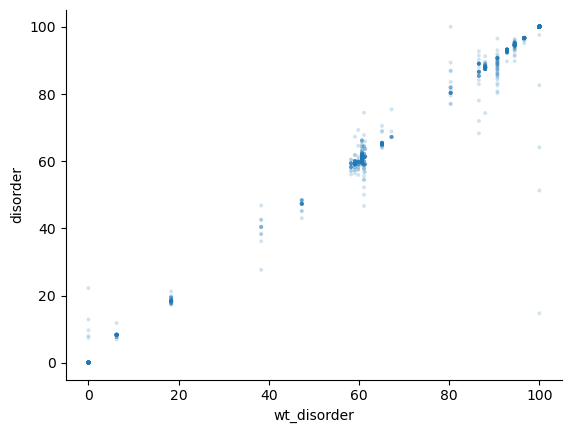

In [7]:
sns.scatterplot(data = all_AD_df, x = "wt_disorder", y = "disorder", s = 8, alpha = 0.2, edgecolor = 'none')
sns.despine()

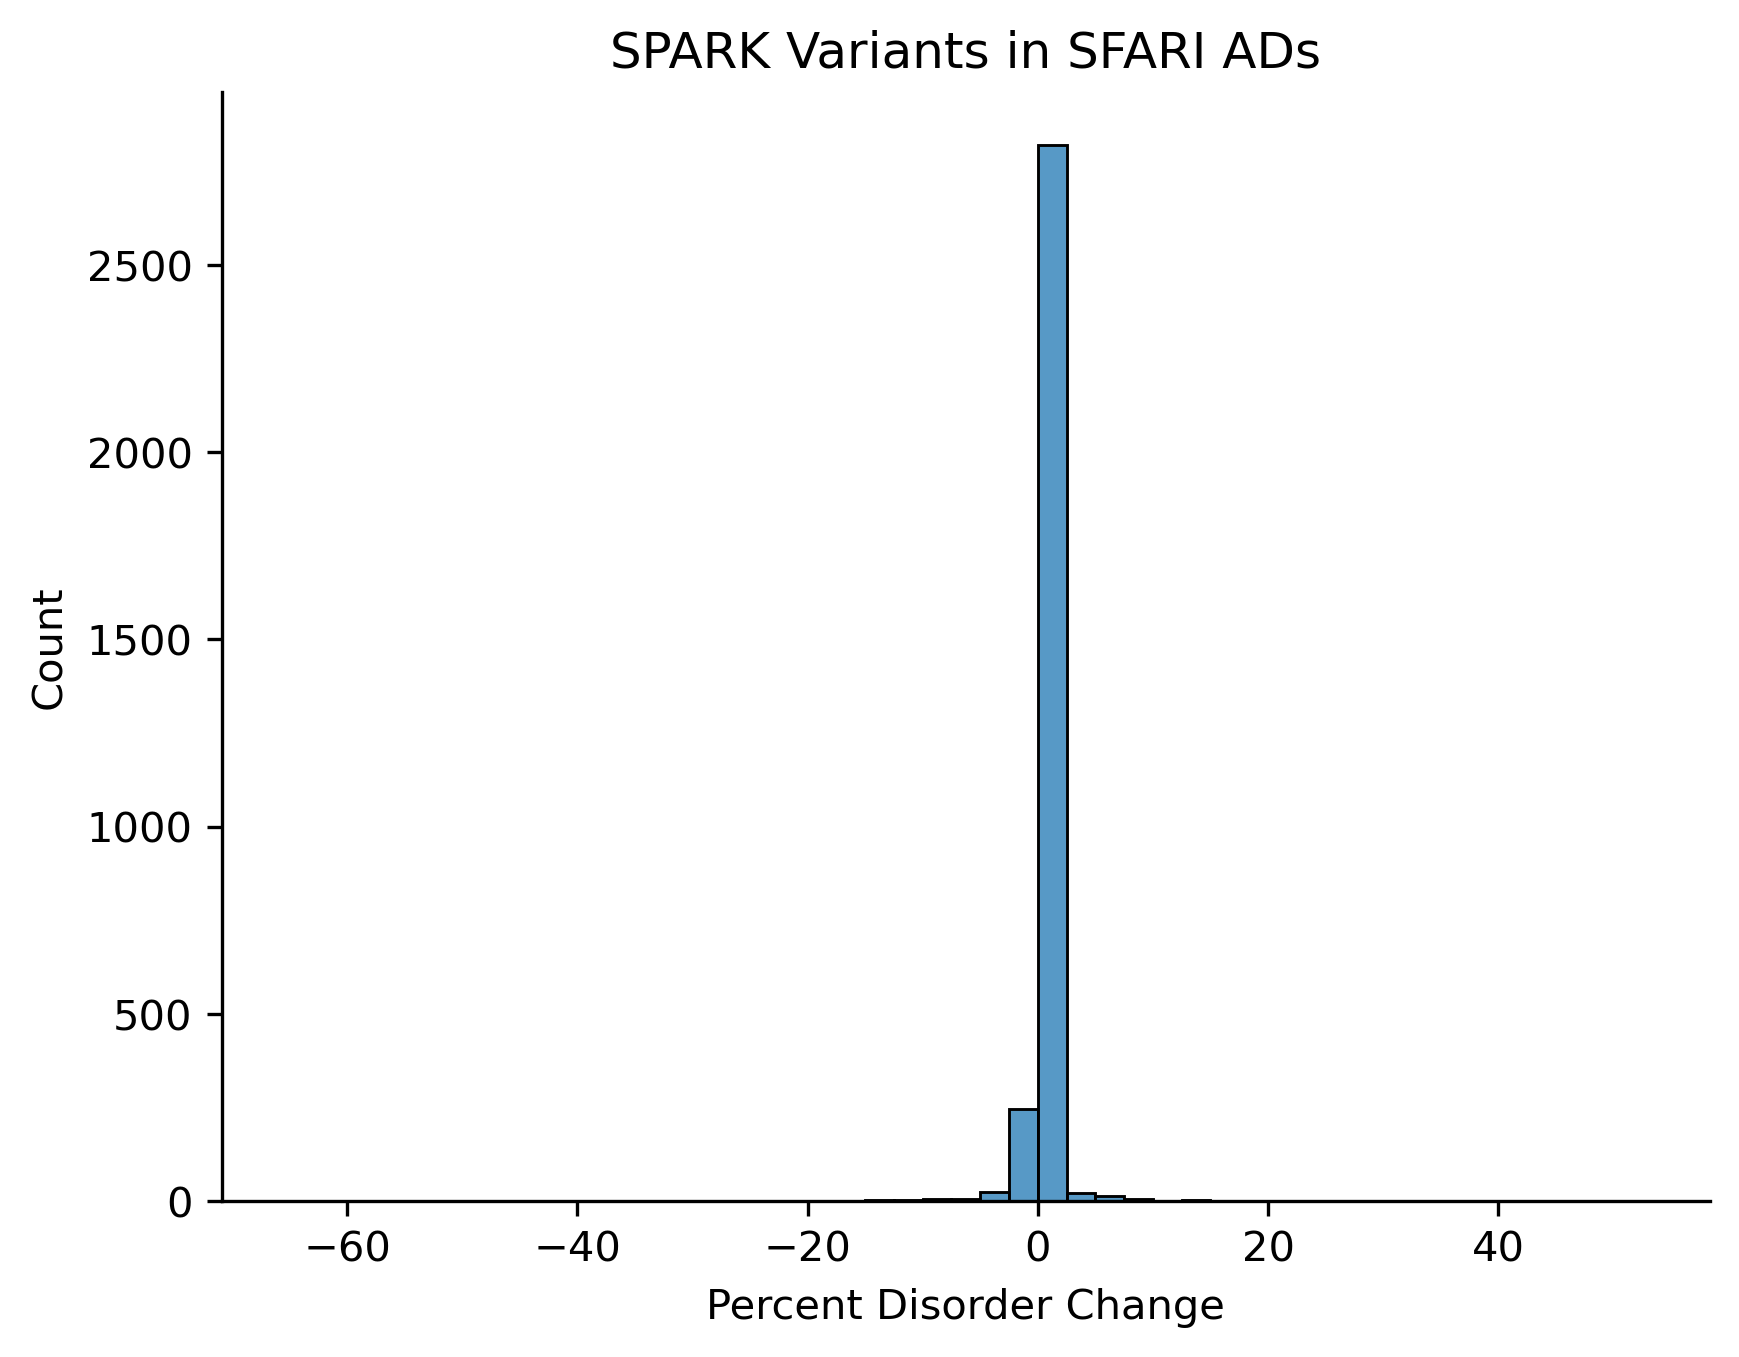

In [8]:
plt.figure(dpi = 300)
sns.histplot(all_AD_df["disorder_diff"], bins = np.arange(-65, 55, 2.5))
plt.xlabel("Percent Disorder Change")
plt.title("SPARK Variants in SFARI ADs")
sns.despine()

In [9]:
AD_names = all_AD_df["name"].unique()
AD_names[:3]

array(['GLIS1_Q8NBF1_AD_447-620', 'RORA_P35398_AD_272-385',
       'VDR_P11473_AD_415-427'], dtype=object)

In [10]:
! mkdir ../output/disorder_pred_figs/

mkdir: ../output/disorder_pred_figs/: File exists


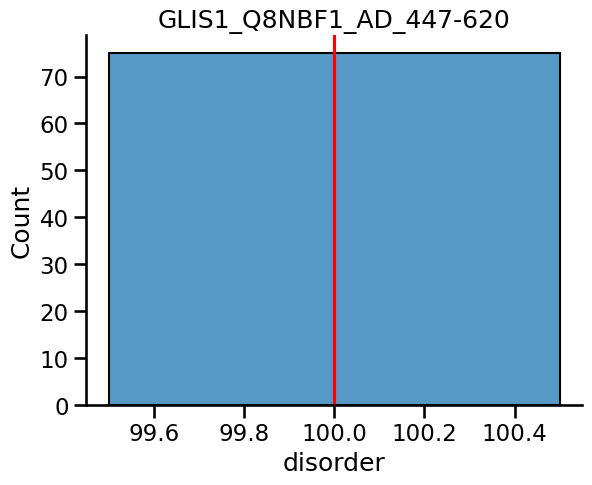

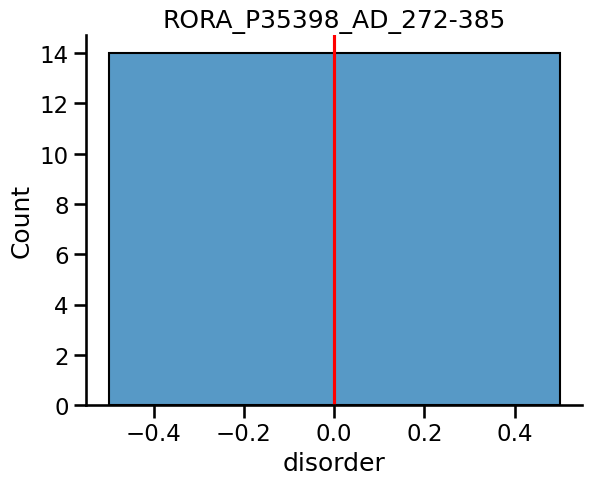

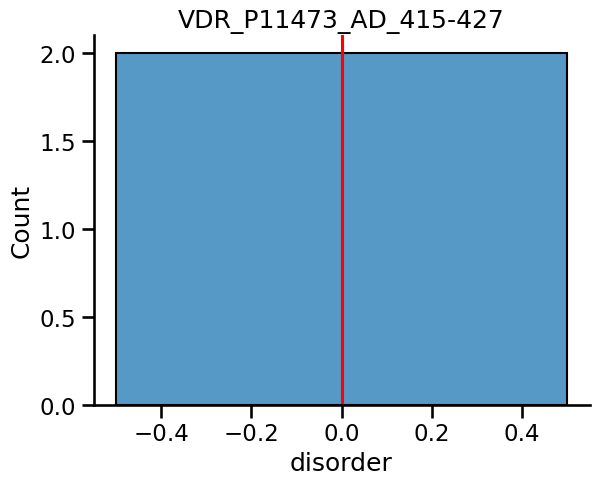

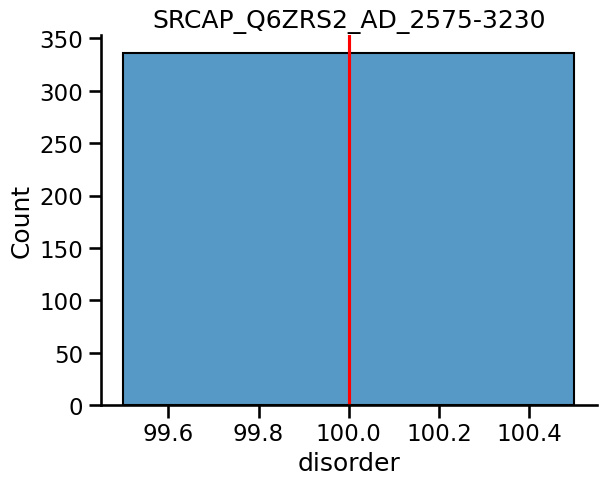

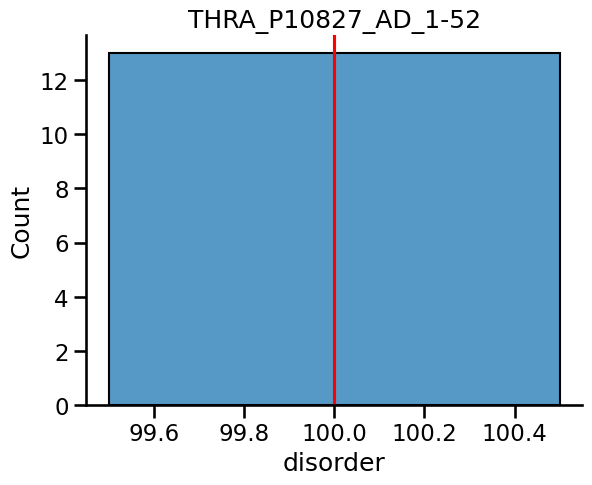

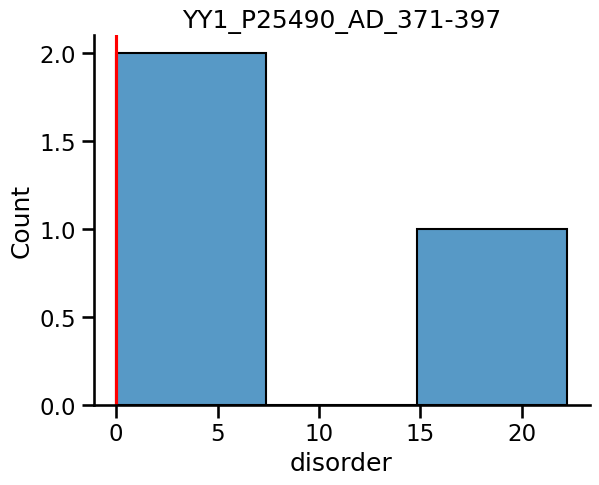

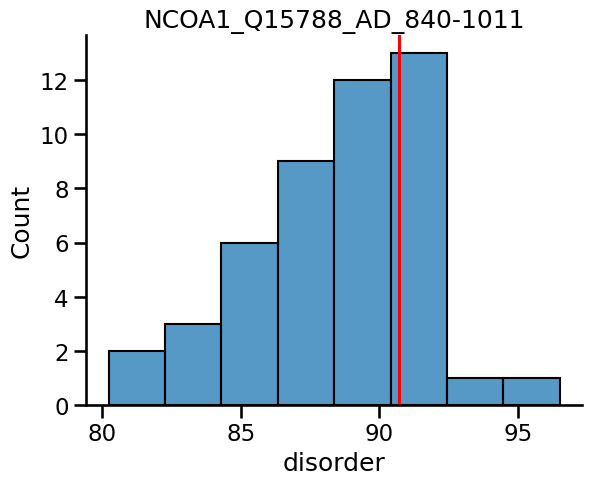

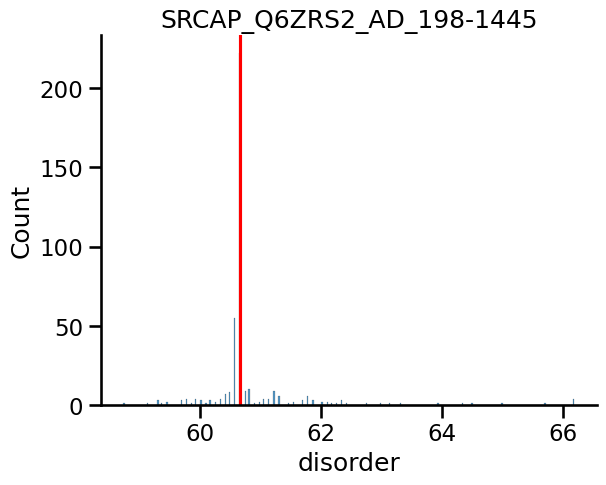

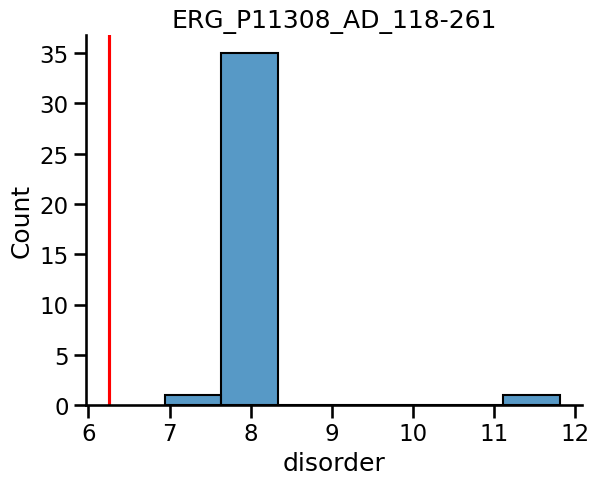

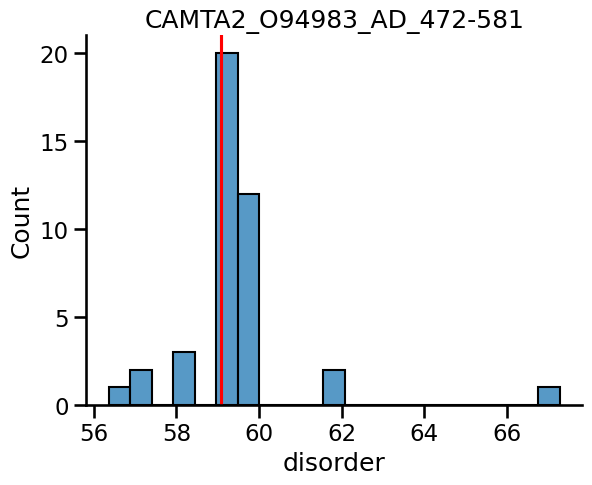

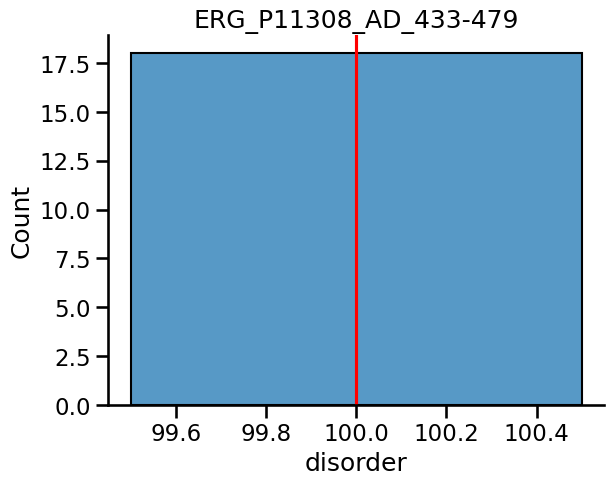

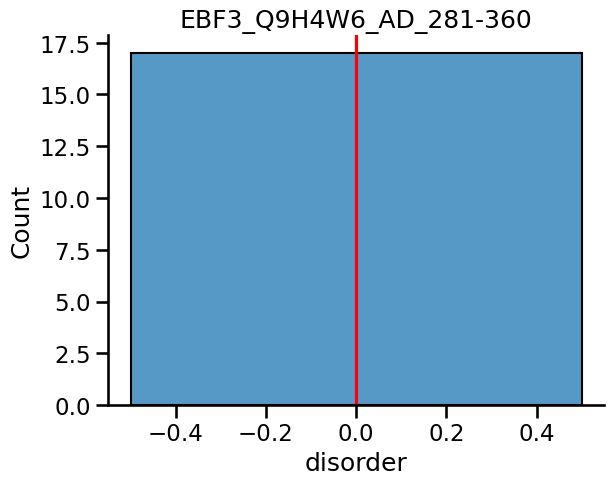

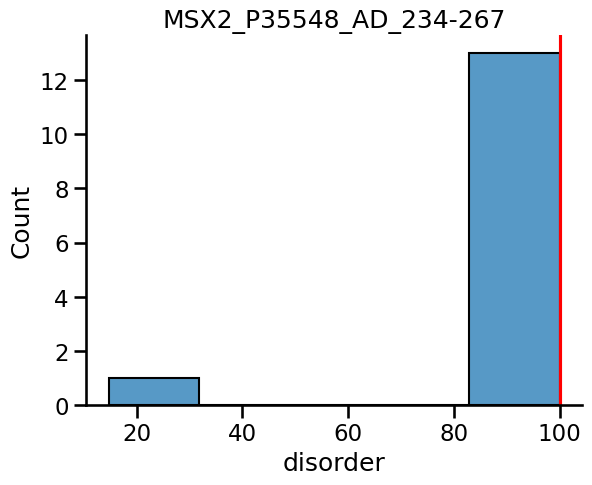

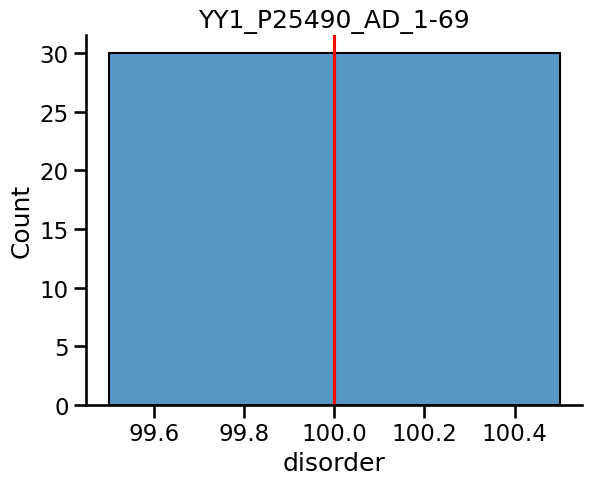

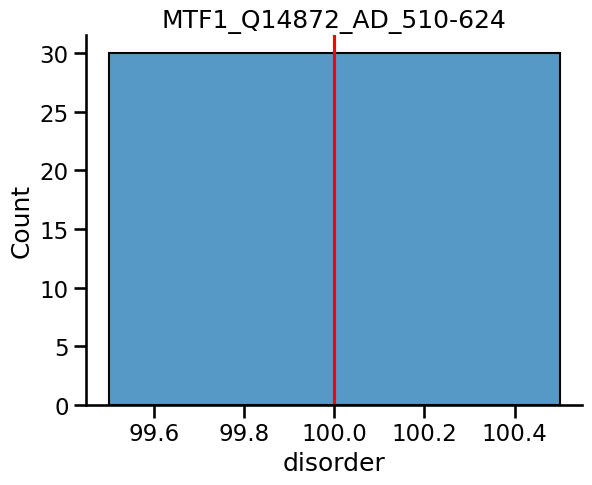

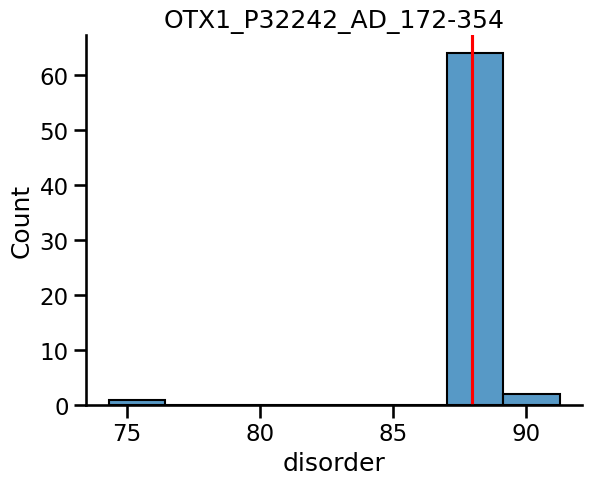

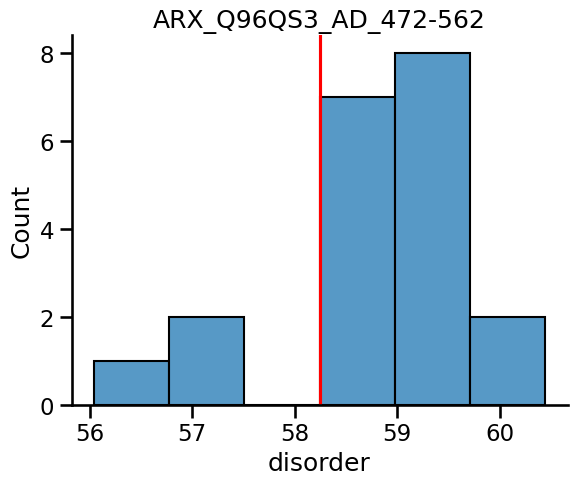

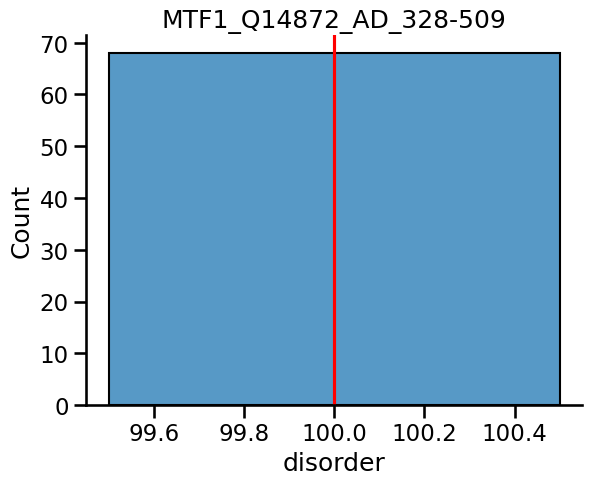

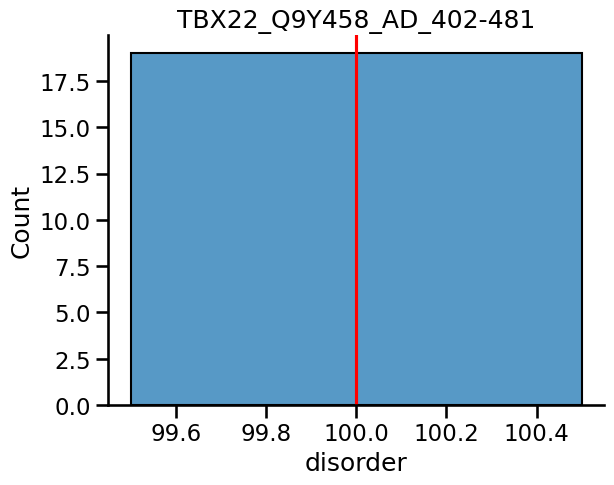

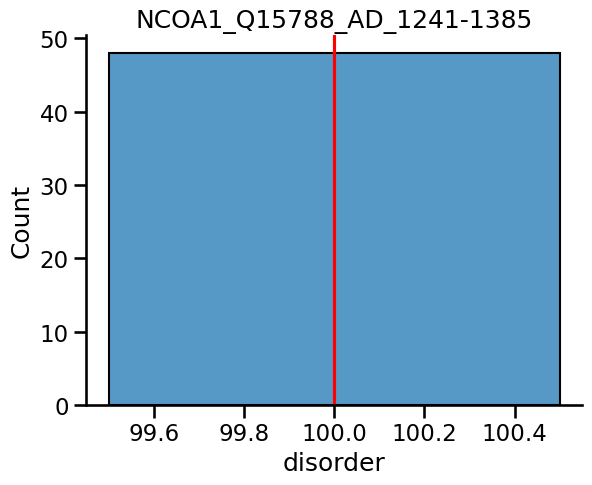

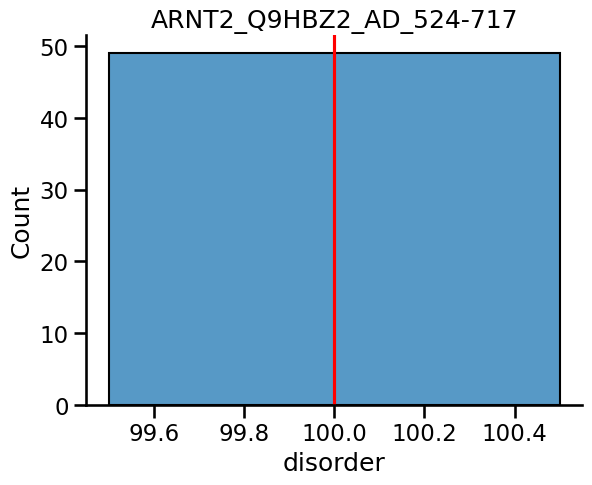

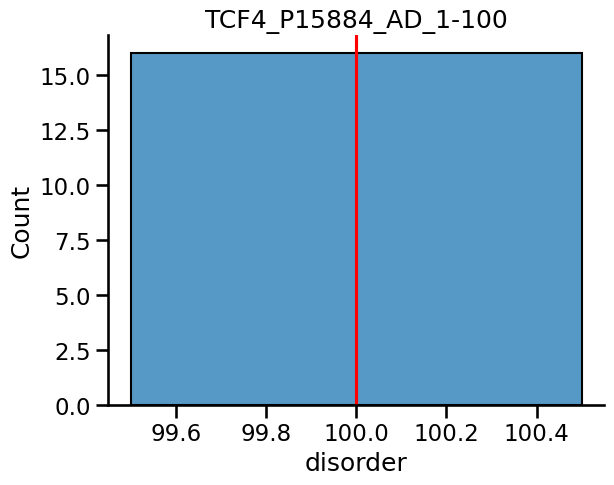

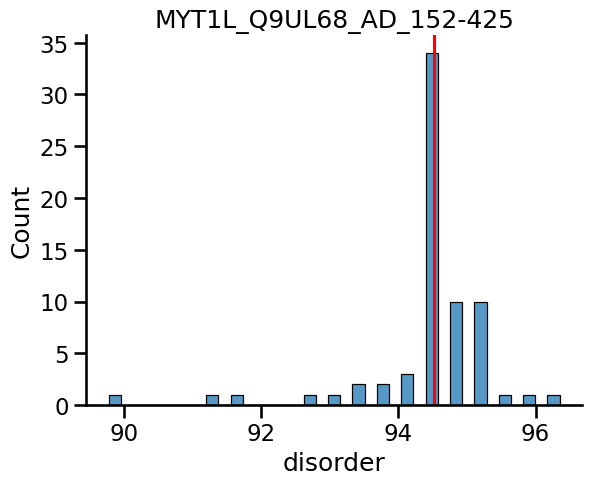

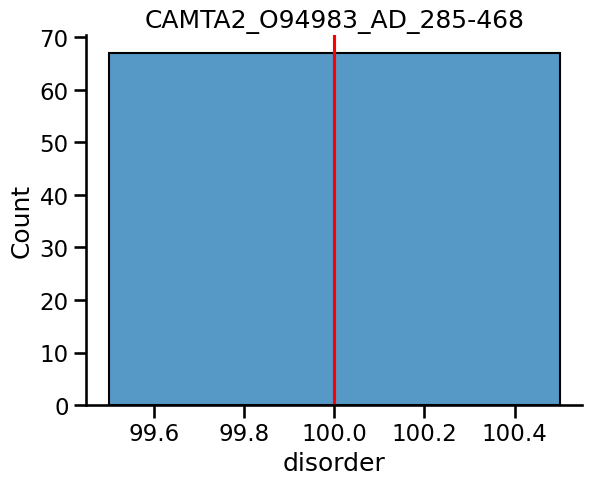

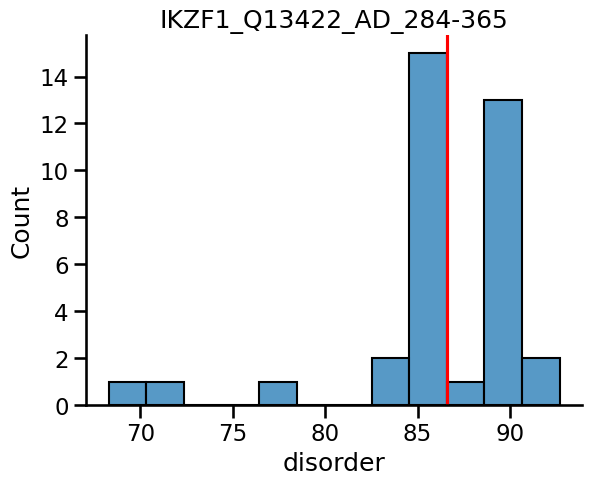

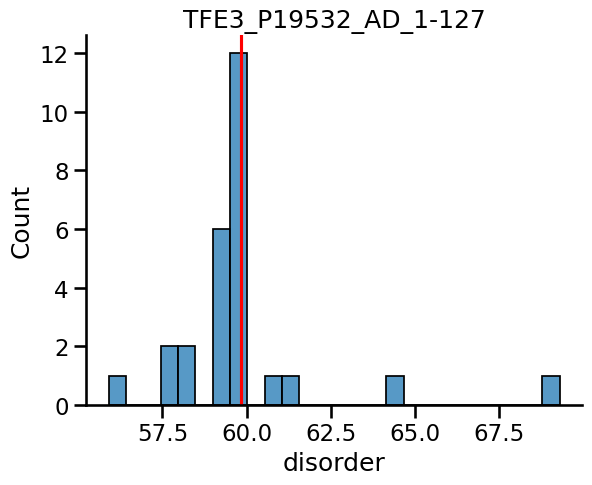

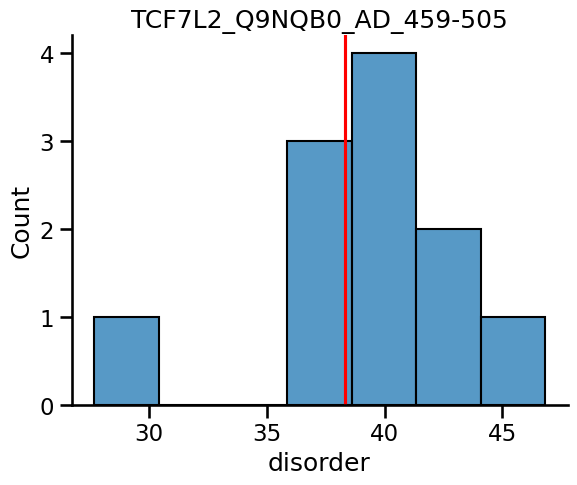

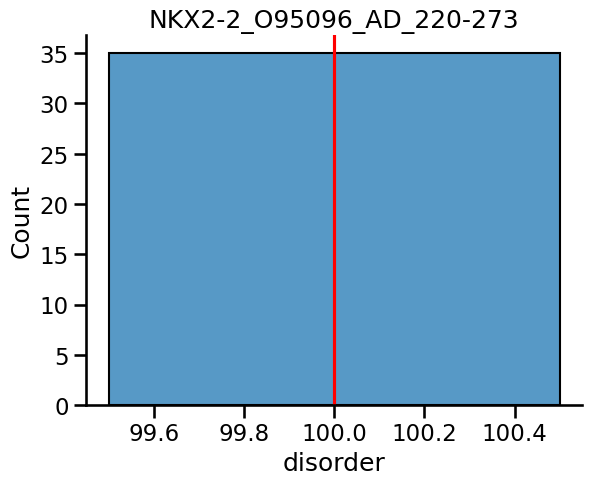

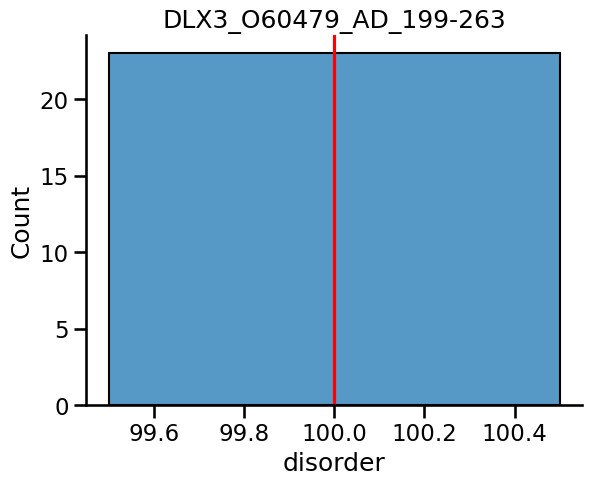

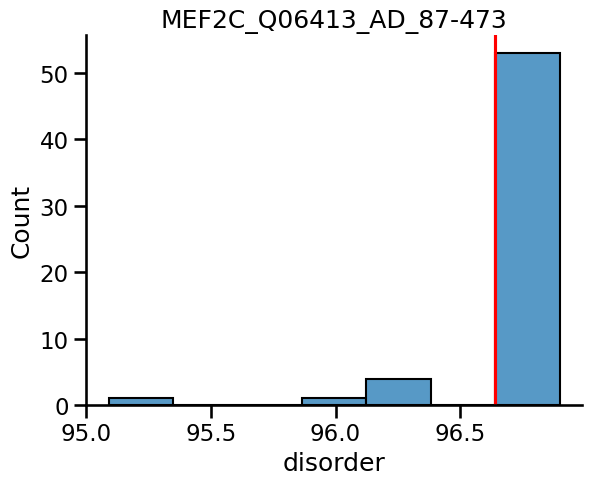

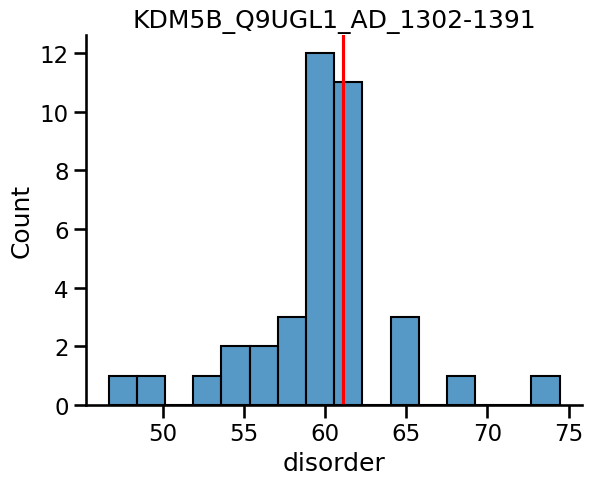

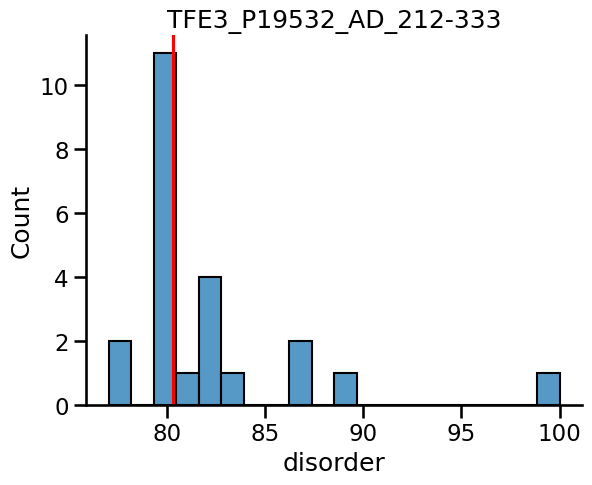

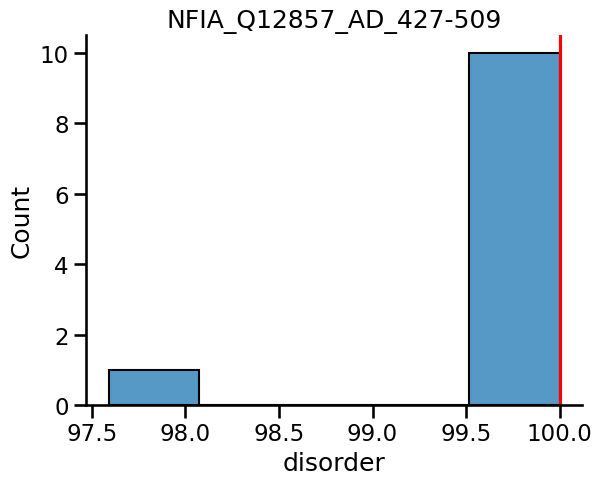

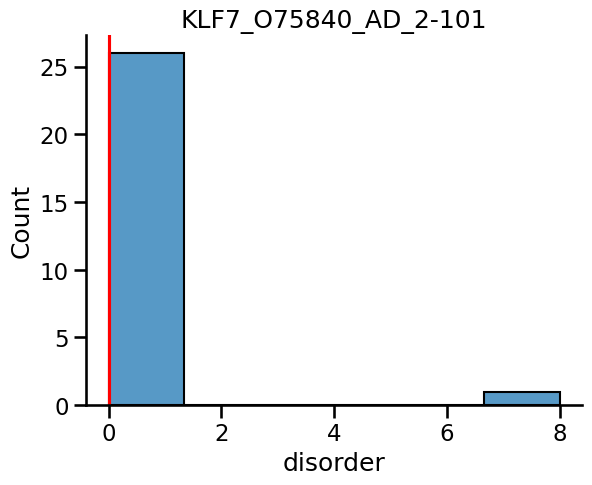

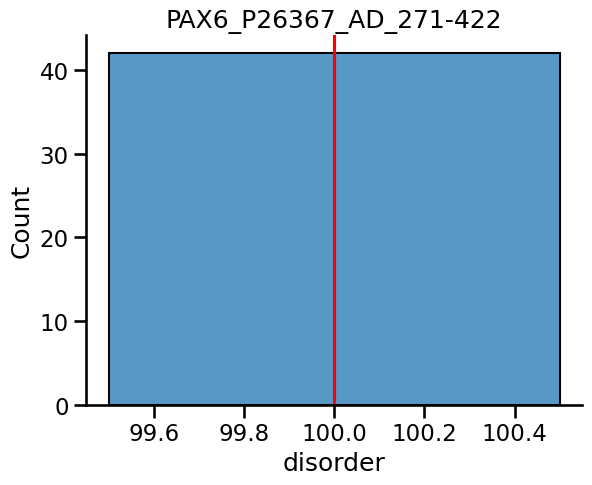

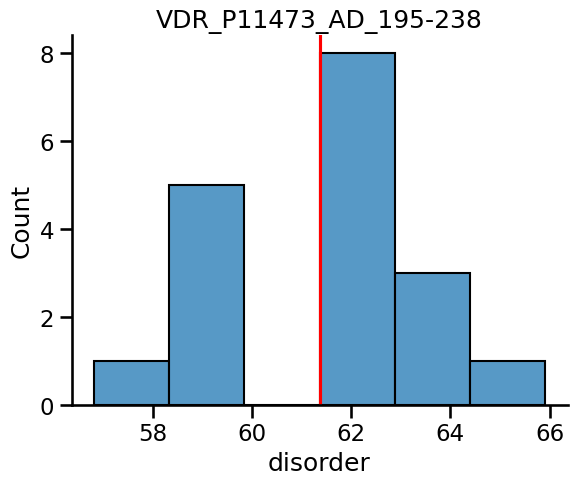

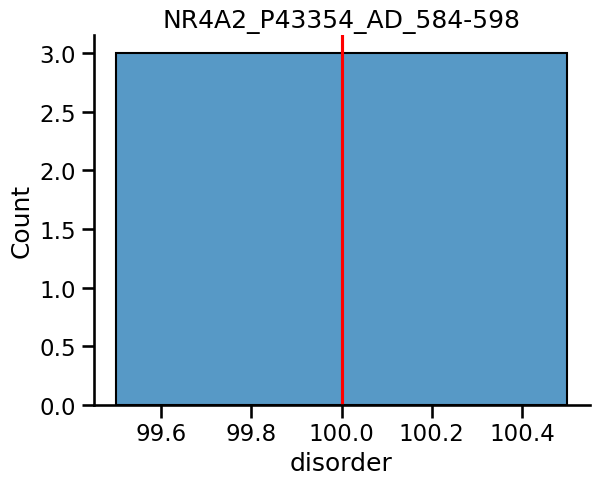

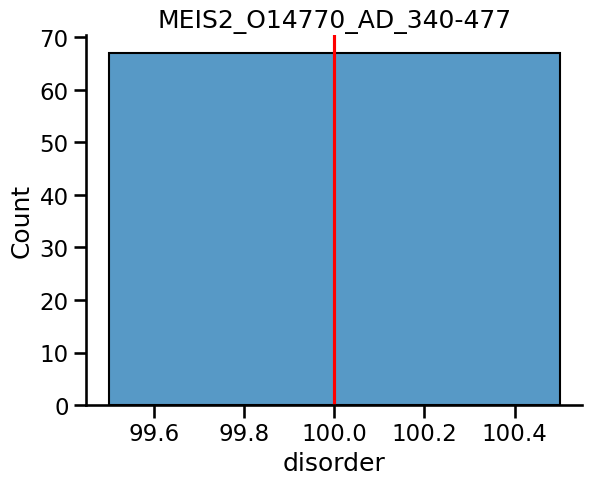

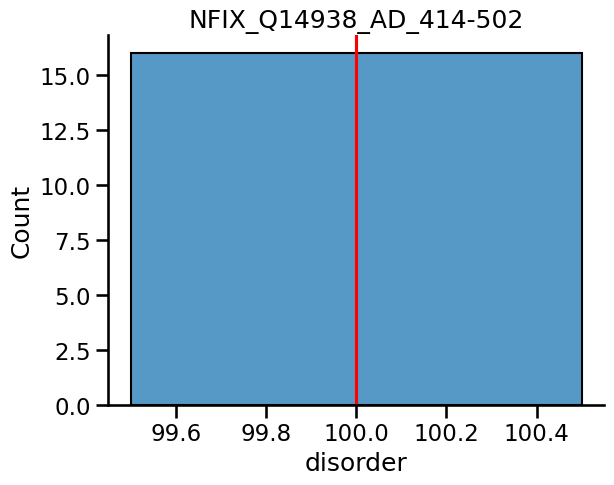

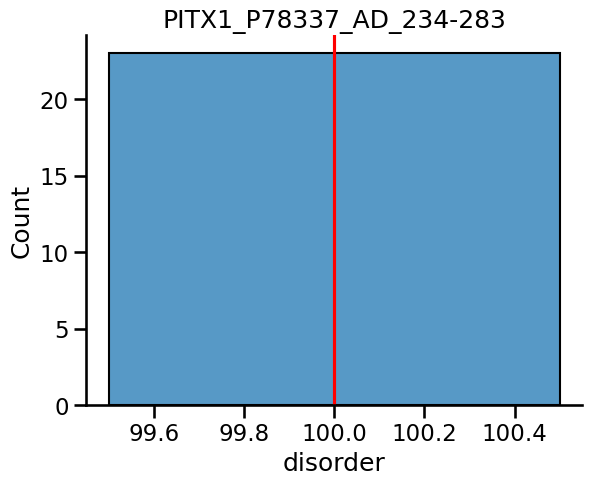

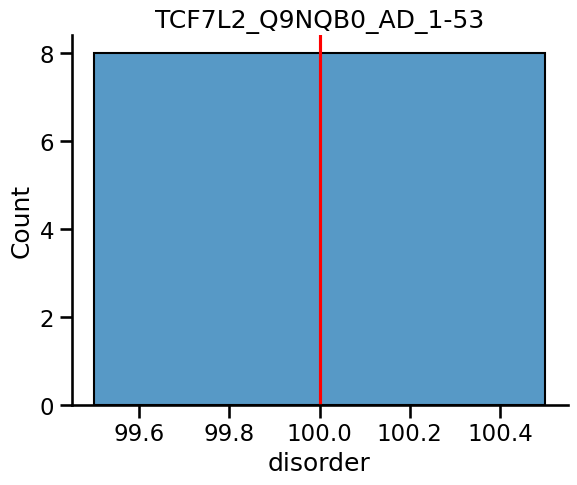

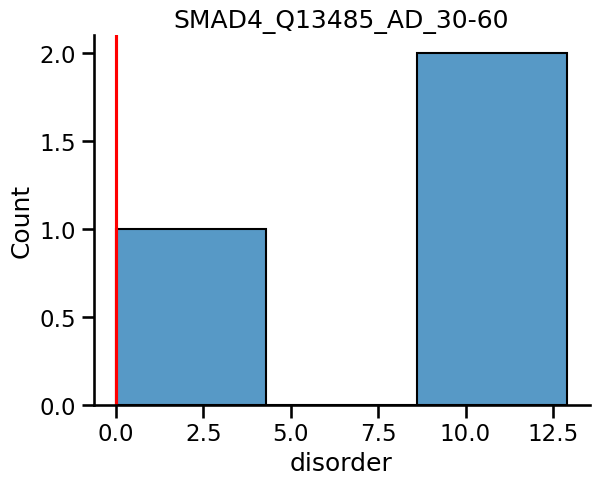

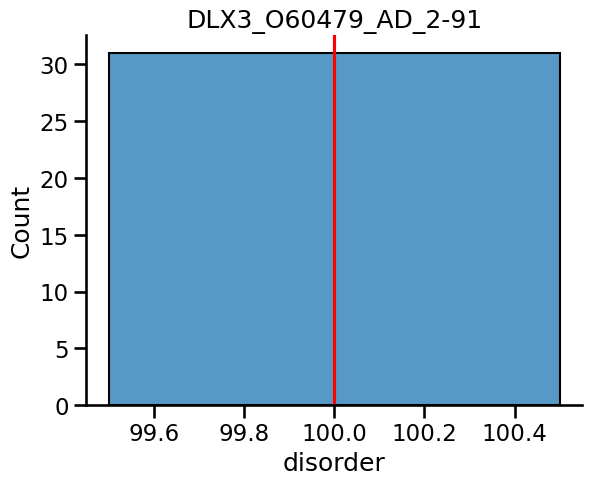

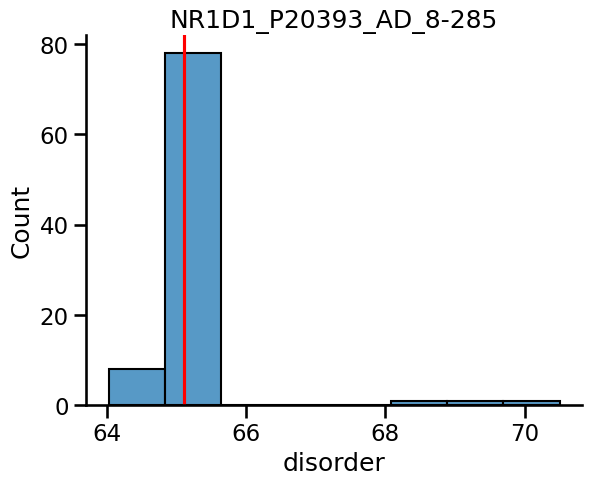

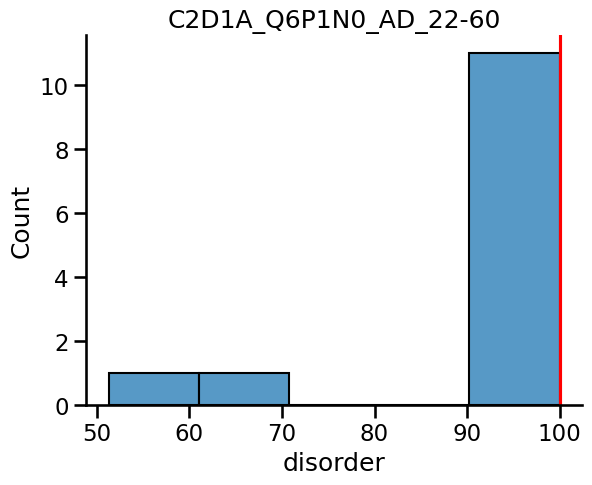

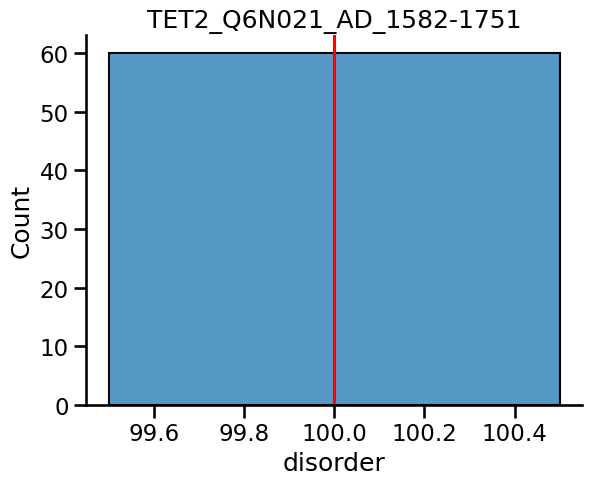

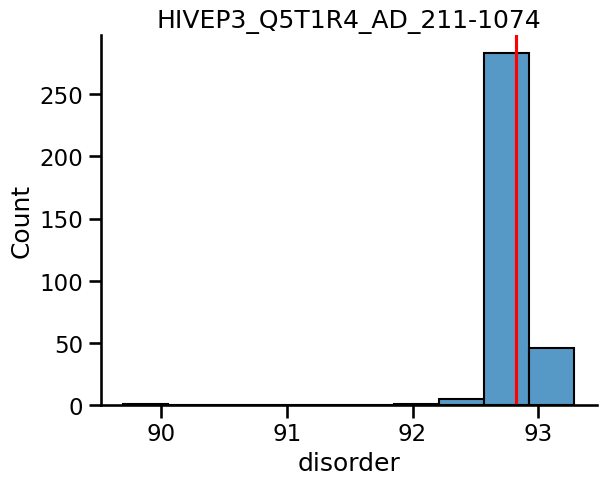

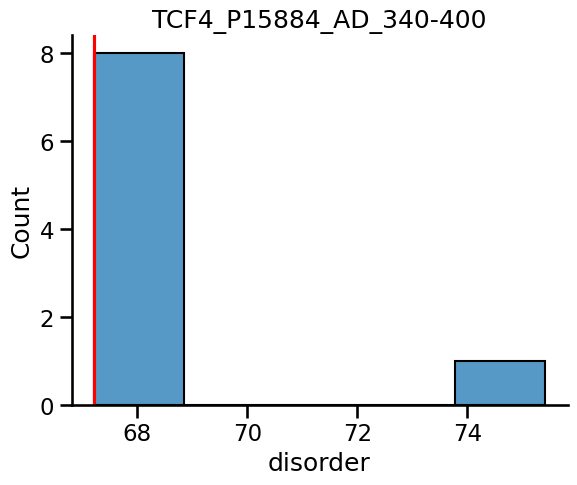

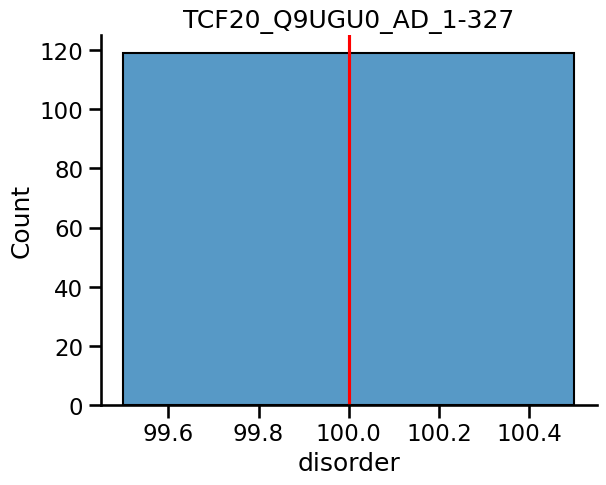

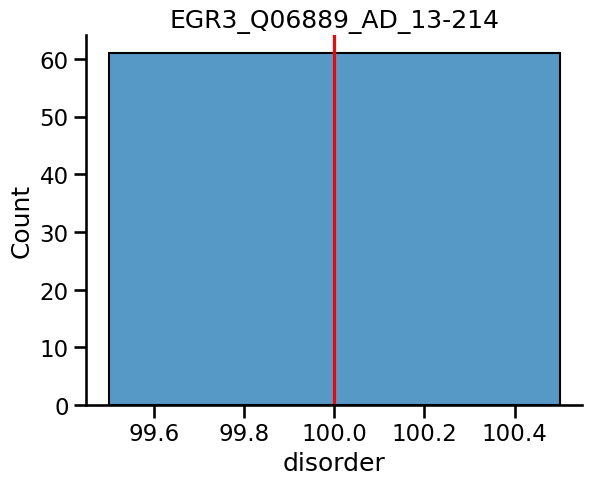

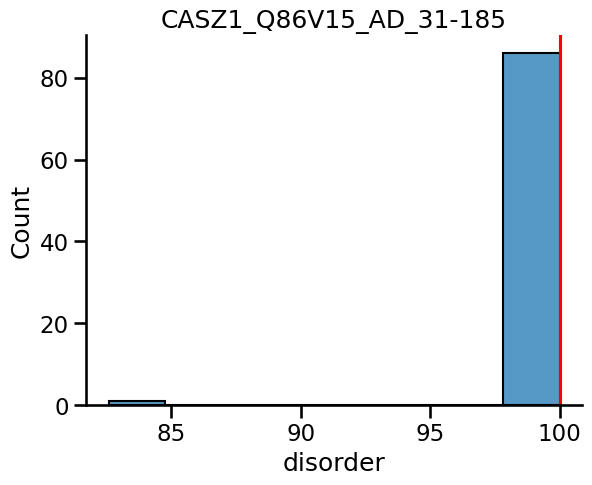

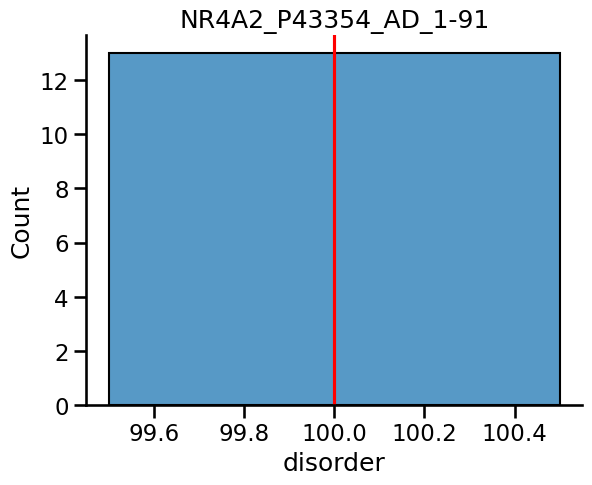

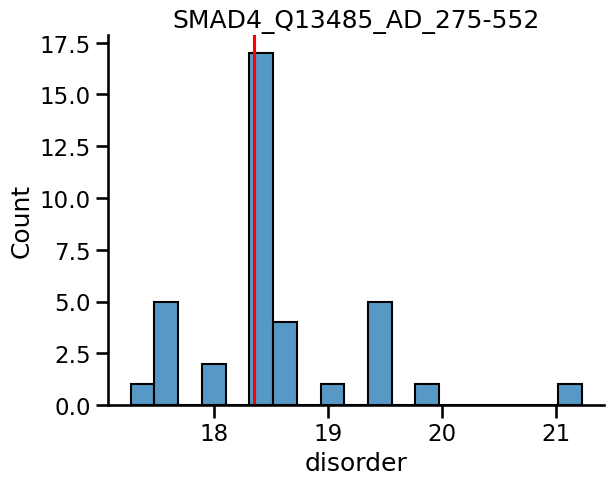

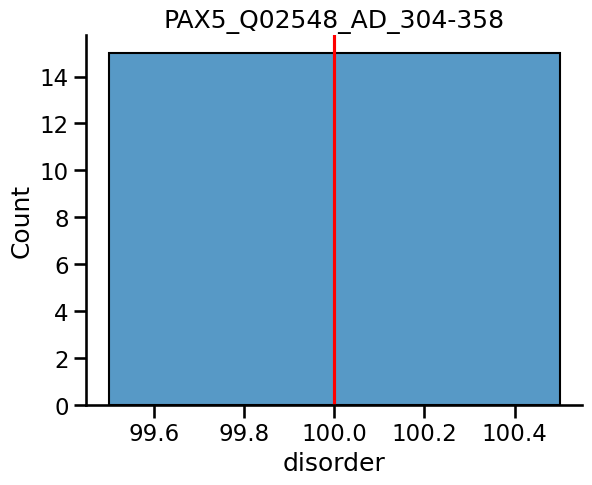

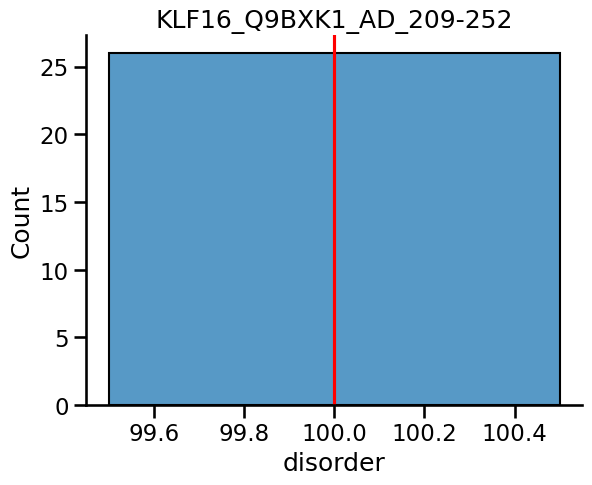

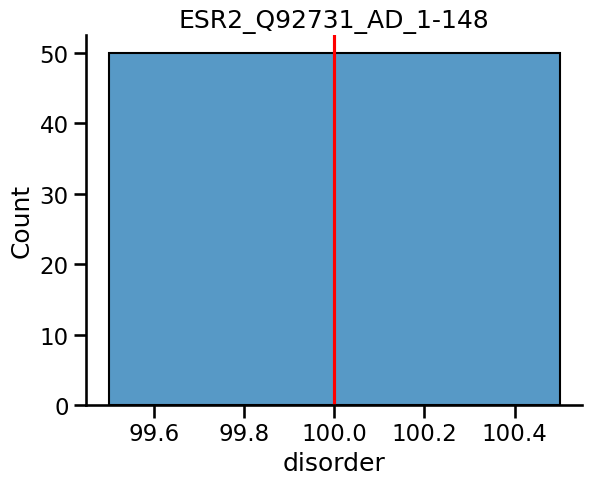

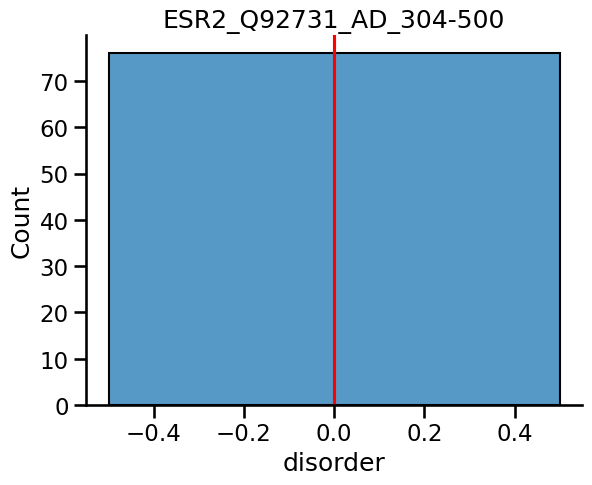

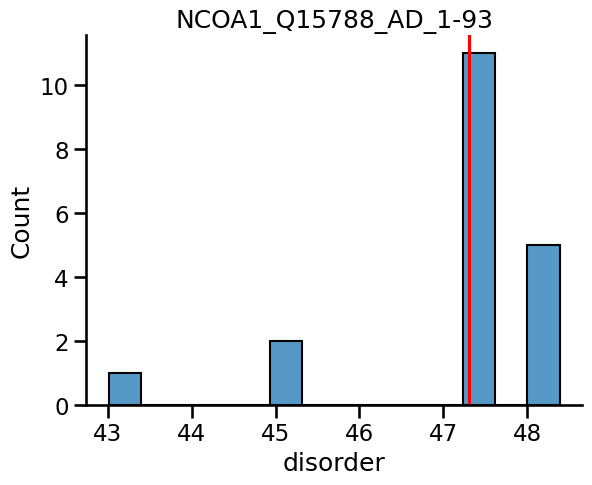

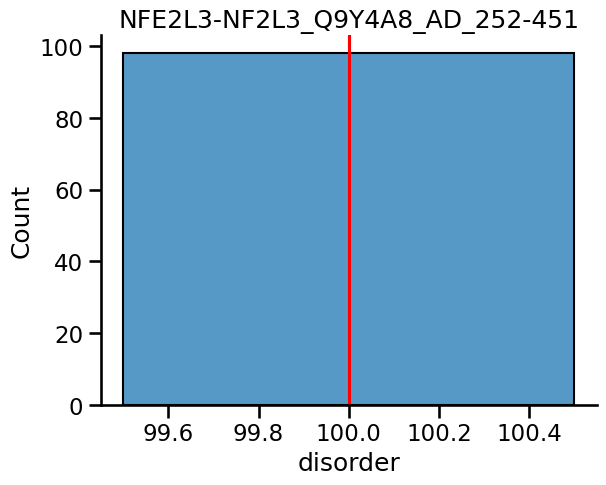

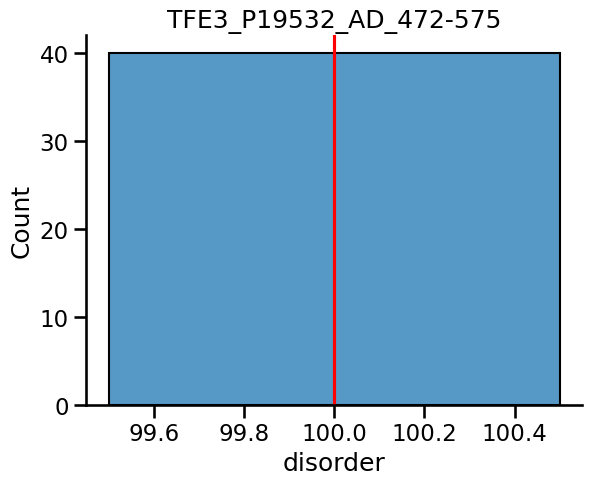

In [11]:
for AD in AD_names:
    single_AD_df = all_AD_df[all_AD_df["name"] == AD]

    sns.set_context('talk')
    sns.histplot(single_AD_df["disorder"])
    plt.axvline(single_AD_df["wt_disorder"].iloc[0], color = 'red')
    sns.despine()
    plt.title(AD)
    plt.savefig("../output/disorder_pred_figs/" + AD)
    plt.show()

In [12]:
all_AD_df["abs_disorder_diff"] = np.abs(all_AD_df["disorder_diff"])

In [13]:
all_AD_df[all_AD_df["abs_disorder_diff"] > 15].sort_values(by = "abs_disorder_diff", ascending = False)

,key,seq,name,wt_disorder,disorder,disorder_diff,abs_disorder_diff
9,g.174729537G>T(p.Gly253Val),SIYGASYPFHRPVLPIPPVVLYATPVGYGMYHLS,MSX2_P35548_AD_234-267,100.000,14.706,-85.294,85.294
12,g.13909919G>A(p.Gly53Arg),GLLVDLSPDGLMIPEDGANDEELEAEFLALVRGQPPALE,C2D1A_Q6P1N0_AD_22-60,100.000,51.282,-48.718,48.718
10,g.13909901G>A(p.Glu47Lys),GLLVDLSPDGLMIPEDGANDEELEAKFLALVGGQPPALE,C2D1A_Q6P1N0_AD_22-60,100.000,64.103,-35.897,35.897
0,g.100277467G>A(p.Arg371His),HTHVRIHTGDRPYVCPFDGCNKKFAQS,YY1_P25490_AD_371-397,0.000,22.222,22.222,22.222
12,g.49038113A>G(p.Ile261Thr),ASQALTPPPGPASAQPLPAPEAAHTTGPTGSAPNSPMALLTIGSSS...,TFE3_P19532_AD_212-333,80.328,100.000,19.672,19.672
15,g.50400092C>G(p.Pro342Arg),GDKGLSDTPYDSSASYEKENEMMKSHVMDQAINNAINYLGAESLRP...,IKZF1_Q13422_AD_284-365,86.585,68.293,-18.292,18.292
42,g.10665289G>A(p.Pro100Leu),LNAICAKLSRQVVVEKRADAGSHTEGSPSQPRDQERSGPESGAARA...,CASZ1_Q86V15_AD_31-185,100.000,82.581,-17.419,17.419


---
# 2. Center tiles around the variants

In [14]:
# make list of all variants

all_AD_dfs = []

for path in glob.glob("../soto_analysis/outputs/AD_variant_fasta_saved/*"):
    AD_dict = protfasta.read_fasta(path)
    
    name = path.split("/")[-1]
    uniprot_ID = name.split("_")[1]
    start = int(name.split("_")[-1].split("-")[0])
    end = int(name.split("_")[-1].split("-")[1])
    
    wt_seq = known_ADs[(known_ADs["uniprotID"].str.contains(uniprot_ID)) & (known_ADs["Start"] == start) & (known_ADs["End"] == end)]["ProteinRegionSeq"].iloc[0]
    
    AD_df = pd.DataFrame({"key" : AD_dict.keys(), "seq" : AD_dict.values()})
    AD_df["name"] = name
    AD_df["uniprotID"] = uniprot_ID
    AD_df["start"] = start
    AD_df["end"] = end


    # AD_df["name"] = name
    # AD_df["wt_disorder"] = metapredict.percent_disorder(wt_seq)
    
    # AD_df["disorder"] = AD_df["seq"].apply(lambda s: metapredict.percent_disorder(s))
    all_AD_dfs.append(AD_df)

In [15]:
all_AD_df = pd.concat(all_AD_dfs)
all_AD_df

,key,seq,name,uniprotID,start,end
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620
...,...,...,...,...,...,...
35,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575
36,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575
37,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575
38,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575


In [16]:
lambert_TFs = pd.read_csv("../output/lambert_TFs_10-21-24_with_DBD_coords.csv")
lambert_TFs["uniprotID"] = lambert_TFs["id"].str.split("|").str[1]
lambert_TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0
...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8


In [17]:
amino_acids = {
    'Ala': 'A',  # Alanine
    'Cys': 'C',  # Cysteine
    'Asp': 'D',  # Aspartic acid
    'Glu': 'E',  # Glutamic acid
    'Phe': 'F',  # Phenylalanine
    'Gly': 'G',  # Glycine
    'His': 'H',  # Histidine
    'Ile': 'I',  # Isoleucine
    'Lys': 'K',  # Lysine
    'Leu': 'L',  # Leucine
    'Met': 'M',  # Methionine
    'Asn': 'N',  # Asparagine
    'Pro': 'P',  # Proline
    'Gln': 'Q',  # Glutamine
    'Arg': 'R',  # Arginine
    'Ser': 'S',  # Serine
    'Thr': 'T',  # Threonine
    'Val': 'V',  # Valine
    'Trp': 'W',  # Tryptophan
    'Tyr': 'Y',  # Tyrosine
}
len(amino_acids)


20

In [18]:
all_AD_df_with_tiles = pd.merge(all_AD_df, lambert_TFs[["uniprotID", "ProteinSeq"]])
all_AD_df_with_tiles["var_pos"] = all_AD_df_with_tiles["key"].str.extract(r'p\....(\d+).*').astype(int)
all_AD_df_with_tiles["var_orig"] = all_AD_df_with_tiles["key"].str.extract(r'p\.(...)')
all_AD_df_with_tiles["var_orig"] = all_AD_df_with_tiles["var_orig"].map(amino_acids)
all_AD_df_with_tiles["var_new"] = all_AD_df_with_tiles["key"].str[-4:-1].map(amino_acids)
all_AD_df_with_tiles

,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,619,D,N
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,618,T,A
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,617,Y,H
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,615,S,F
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,L
...,...,...,...,...,...,...,...,...,...,...
3152,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,476,T,M
3153,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,V
3154,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,T
3155,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,473,G,D


In [19]:
new_protein_seqs = []

for i in all_AD_df_with_tiles.index:
    row = all_AD_df_with_tiles.iloc[i]
    protein_seq = row["ProteinSeq"]

    new_protein_seq = ""
    
    if protein_seq[row["var_pos"] - 1] == row["var_orig"]:
        for i in range(len(protein_seq)):
            if i == row["var_pos"] - 1:
                new_protein_seq += row["var_new"]
            else:
                new_protein_seq += protein_seq[i]
        new_protein_seqs.append(new_protein_seq)
    else:
        print(row['name'])
        new_protein_seqs.append("")
    
    

    # ERG has error, wrong full sequence here.
    

ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_118-261
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308_AD_433-479
ERG_P11308

In [20]:
all_AD_df_with_tiles["var_ProteinSeq"] = new_protein_seqs
all_AD_df_with_tiles

,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new,var_ProteinSeq
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,619,D,N,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,618,T,A,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,617,Y,H,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,615,S,F,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,L,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...
...,...,...,...,...,...,...,...,...,...,...,...
3152,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,476,T,M,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...
3153,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,V,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...
3154,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,T,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...
3155,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,473,G,D,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...


In [21]:
sum(all_AD_df_with_tiles["ProteinSeq"] == all_AD_df_with_tiles["var_ProteinSeq"])
# Matches expected! 

0

In [22]:
all_AD_df_with_tiles["centered_start"] = all_AD_df_with_tiles["var_pos"] - 20
all_AD_df_with_tiles["centered_end"] = all_AD_df_with_tiles["var_pos"] + 20
all_AD_df_with_tiles

,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new,var_ProteinSeq,centered_start,centered_end
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,619,D,N,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,599,639
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,618,T,A,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,598,638
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,617,Y,H,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,597,637
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,615,S,F,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,595,635
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,L,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,594,634
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,476,T,M,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,456,496
3153,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,V,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494
3154,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,T,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494
3155,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,473,G,D,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,453,493


In [23]:
new_var_tiles = []
new_wt_tiles = []


for i in all_AD_df_with_tiles.index:
    row = all_AD_df_with_tiles.iloc[i]
    start = row["centered_start"]
    end = row["centered_end"]
    
    # Start before protein = you want as close to start as possible
    if row["centered_start"] < 0:
        start = start - row["centered_start"] # Start becomes zero
        end = end - row["centered_start"] # Shift end accordingly

    # End is longer than the protein = you want as close to end as possible
    if row["centered_end"] > len(row["var_ProteinSeq"]): 
        end = len(row["var_ProteinSeq"]) # End at length of protein
        start = end - 40 # Start 40 before
    
    var_tile = row["var_ProteinSeq"][start:end]
    wt_tile = row["ProteinSeq"][start:end]

    new_var_tiles.append(var_tile)
    new_wt_tiles.append(wt_tile)


In [24]:
all_AD_df_with_tiles["var_tile"] = new_var_tiles
all_AD_df_with_tiles["wt_tile"] = new_wt_tiles
all_AD_df_with_tiles

,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new,var_ProteinSeq,centered_start,centered_end,var_tile,wt_tile
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,619,D,N,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,599,639,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTNT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,618,T,A,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,598,638,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYADT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,617,Y,H,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,597,637,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIHTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,615,S,F,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,595,635,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPFIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,L,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,594,634,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHILSIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,476,T,M,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,456,496,DSLKPEQLDIEEEGRPGAAMFHVGGGPAQNAPHQQPPAPP,DSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPAPP
3153,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,V,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGVATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA
3154,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,T,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGTATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA
3155,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,473,G,D,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,453,493,SASDSLKPEQLDIEEEGRPDAATFHVGGGPAQNAPHQQPP,SASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPP


In [25]:
all_AD_df_with_tiles_no_ERG = all_AD_df_with_tiles[all_AD_df_with_tiles["var_tile"] != ""]

In [26]:
all_AD_df_with_tiles_no_ERG["var_tile_disord"] = all_AD_df_with_tiles_no_ERG["var_tile"].apply(lambda s: metapredict.percent_disorder(s))
all_AD_df_with_tiles_no_ERG["wt_tile_disord"] = all_AD_df_with_tiles_no_ERG["wt_tile"].apply(lambda s: metapredict.percent_disorder(s))
all_AD_df_with_tiles_no_ERG

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_60857/3578405307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_AD_df_with_tiles_no_ERG["var_tile_disord"] = all_AD_df_with_tiles_no_ERG["var_tile"].apply(lambda s: metapredict.percent_disorder(s))
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_60857/3578405307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_AD_df_with_tiles_no_ERG["wt_tile_disord"] = all_AD_df_with_tiles_no_ERG["wt_tile"].apply(lambda s: metapredict.per

,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new,var_ProteinSeq,centered_start,centered_end,var_tile,wt_tile,var_tile_disord,wt_tile_disord
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,619,D,N,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,599,639,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTNT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,618,T,A,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,598,638,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYADT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,617,Y,H,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,597,637,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIHTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,615,S,F,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,595,635,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPFIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,62.5,100.0
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,L,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,594,634,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHILSIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,60.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,476,T,M,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,456,496,DSLKPEQLDIEEEGRPGAAMFHVGGGPAQNAPHQQPPAPP,DSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPAPP,100.0,100.0
3153,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,V,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGVATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA,100.0,100.0
3154,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,T,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGTATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA,100.0,100.0
3155,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,473,G,D,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,453,493,SASDSLKPEQLDIEEEGRPDAATFHVGGGPAQNAPHQQPP,SASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPP,100.0,100.0


In [27]:
all_AD_df_with_tiles_no_ERG["disord_diff"] = all_AD_df_with_tiles_no_ERG["var_tile_disord"] - all_AD_df_with_tiles_no_ERG["wt_tile_disord"]
all_AD_df_with_tiles_no_ERG

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_60857/3527505632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_AD_df_with_tiles_no_ERG["disord_diff"] = all_AD_df_with_tiles_no_ERG["var_tile_disord"] - all_AD_df_with_tiles_no_ERG["wt_tile_disord"]


,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new,var_ProteinSeq,centered_start,centered_end,var_tile,wt_tile,var_tile_disord,wt_tile_disord,disord_diff
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,619,D,N,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,599,639,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTNT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,618,T,A,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,598,638,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYADT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,617,Y,H,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,597,637,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIHTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,615,S,F,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,595,635,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPFIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,62.5,100.0,-37.5
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,L,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,594,634,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHILSIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,60.0,100.0,-40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,476,T,M,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,456,496,DSLKPEQLDIEEEGRPGAAMFHVGGGPAQNAPHQQPPAPP,DSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPAPP,100.0,100.0,0.0
3153,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,V,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGVATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA,100.0,100.0,0.0
3154,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,T,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGTATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA,100.0,100.0,0.0
3155,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,473,G,D,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,453,493,SASDSLKPEQLDIEEEGRPDAATFHVGGGPAQNAPHQQPP,SASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPP,100.0,100.0,0.0


In [28]:
min(all_AD_df_with_tiles_no_ERG["disord_diff"])

-100.0

In [29]:
max(all_AD_df_with_tiles_no_ERG["disord_diff"])

92.5

Text(0.5, 0, 'Percent Disorder Difference, 40AA Tile')

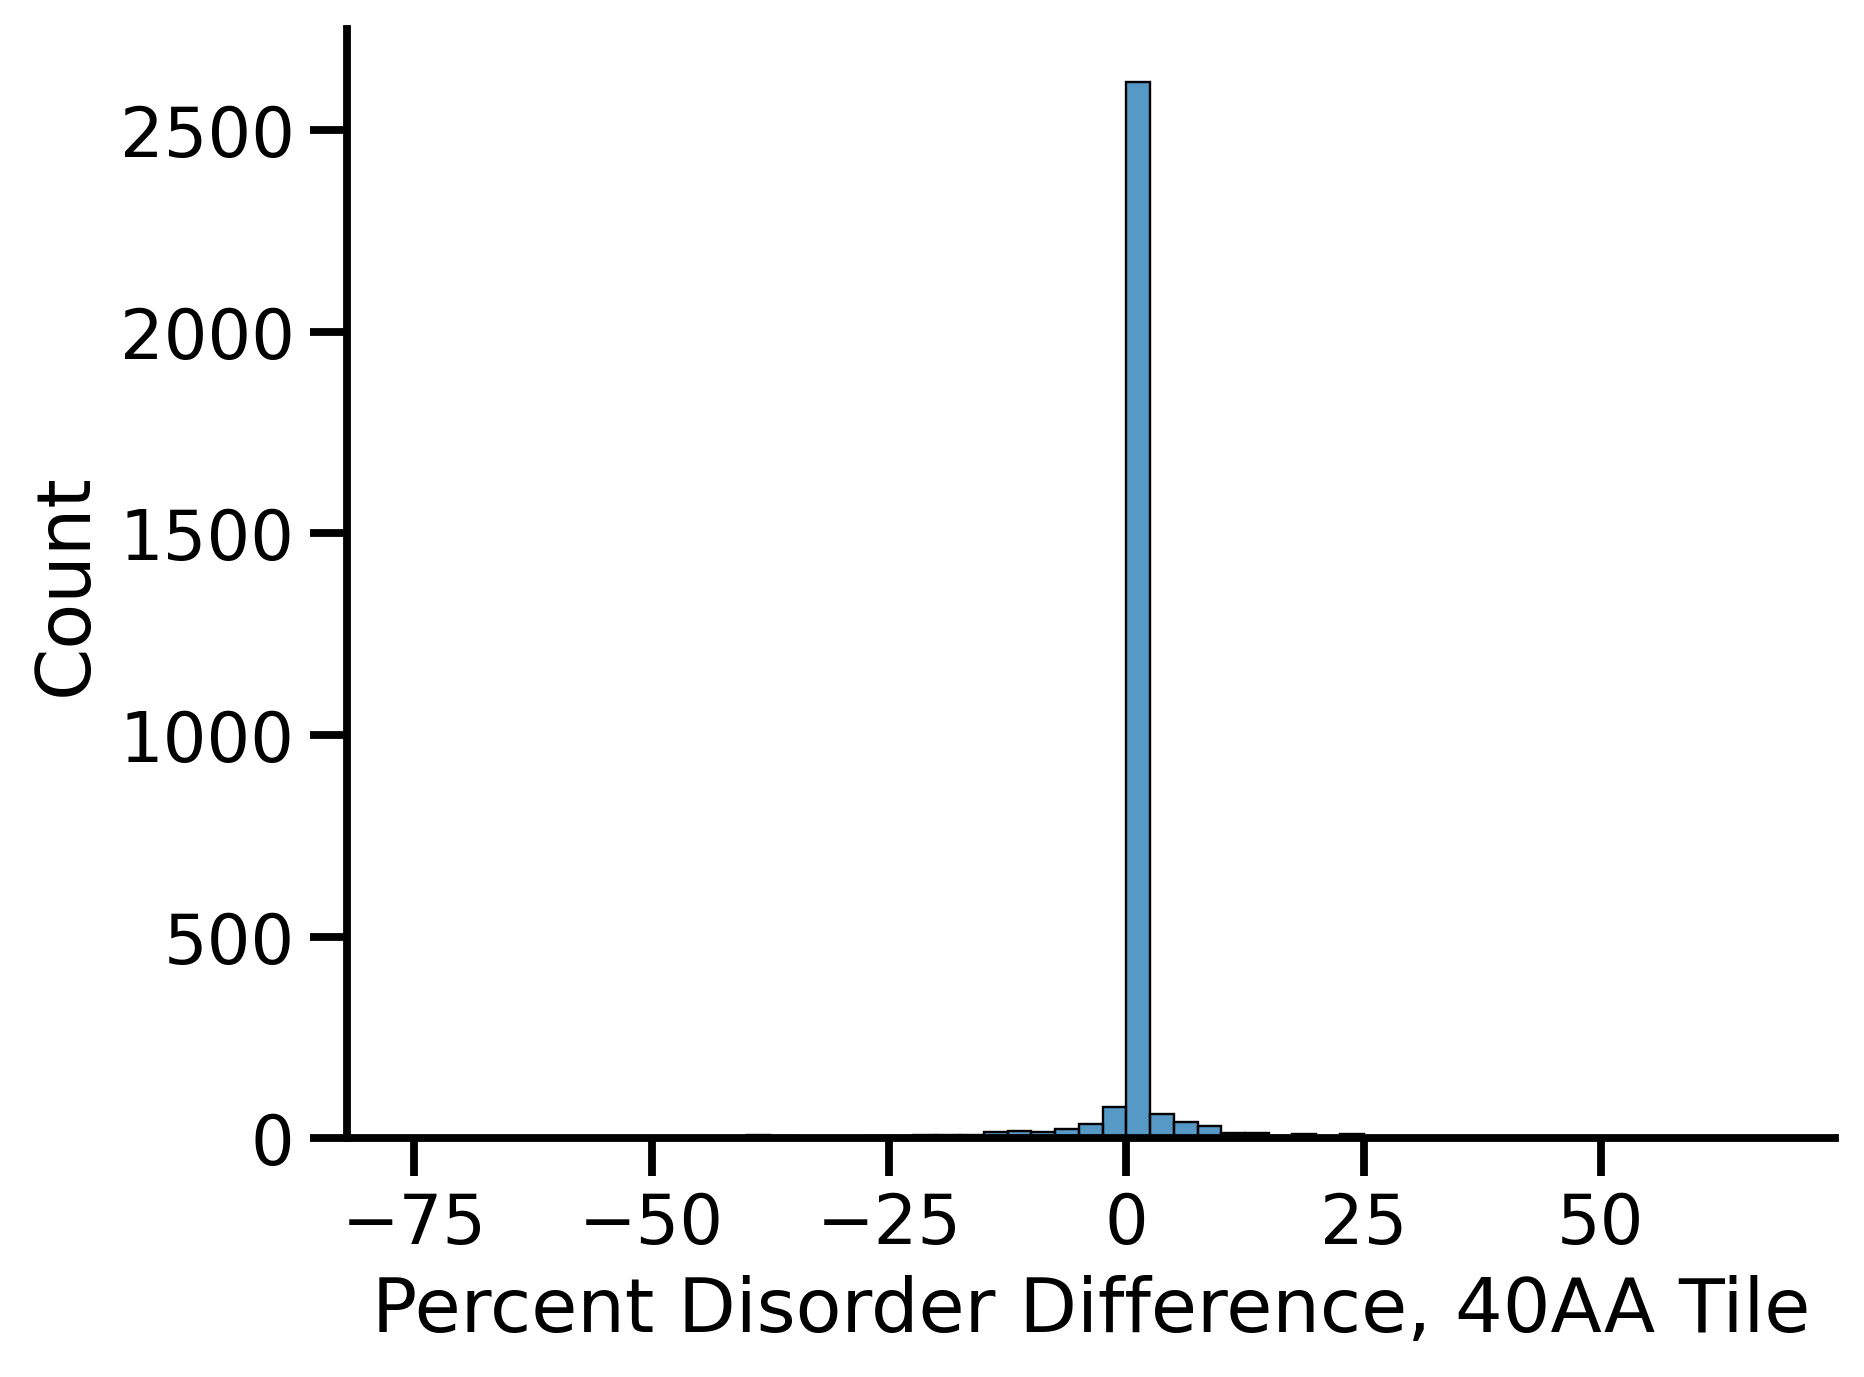

In [65]:
plt.figure(dpi = 300)
sns.histplot(all_AD_df_with_tiles_no_ERG["disord_diff"], bins = np.arange(-75, 70, 2.5))
sns.despine()
plt.xlabel("Percent Disorder Difference, 40AA Tile")

Text(0.5, 0, 'Percent Disorder Difference, 40AA Tile')

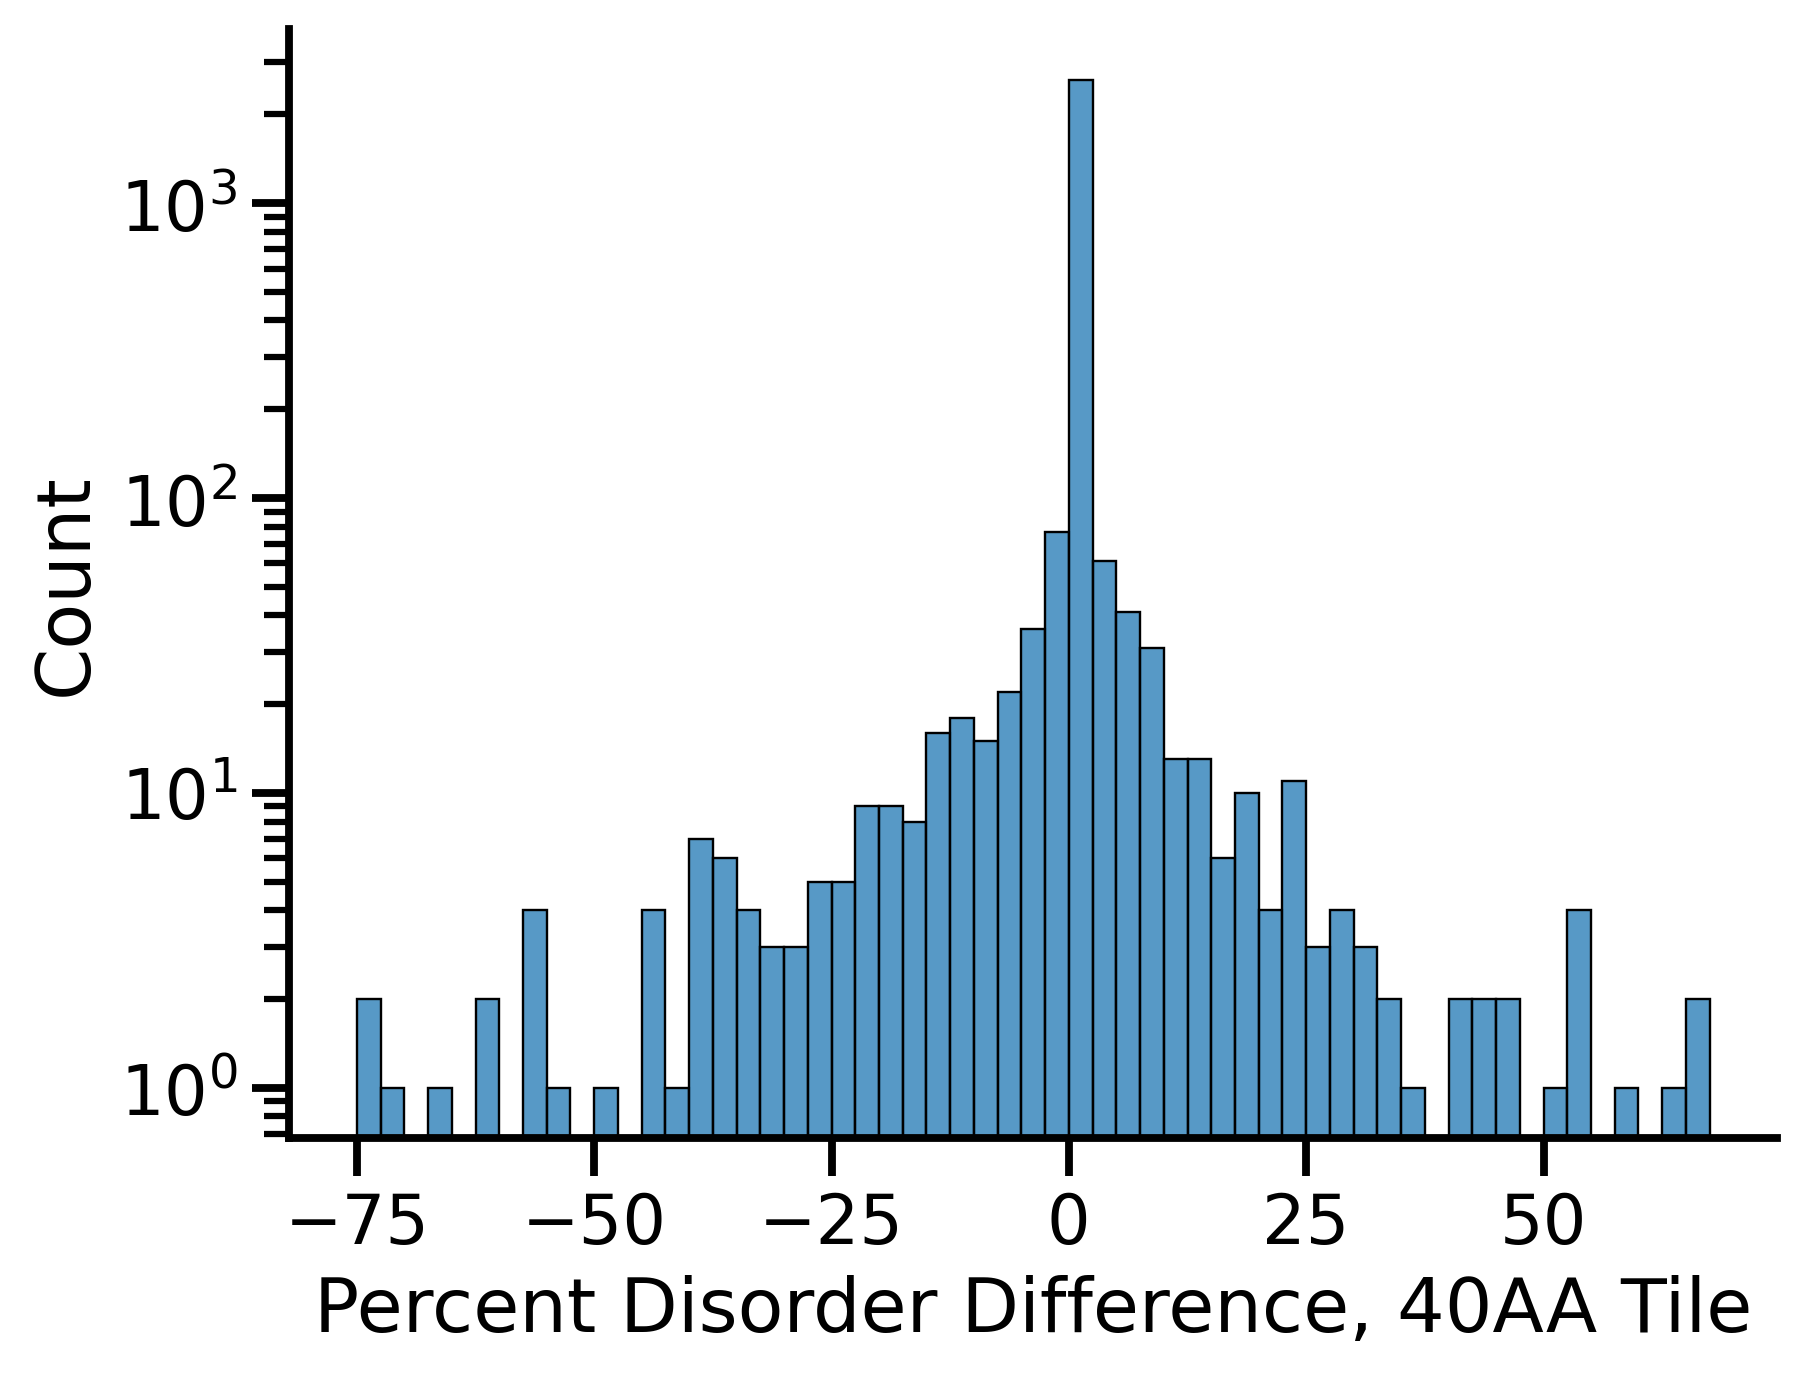

In [64]:
plt.style.use('default')
sns.set_context('talk')
plt.figure(dpi = 300)
ax = sns.histplot(all_AD_df_with_tiles_no_ERG["disord_diff"], bins = np.arange(-75, 70, 2.5))
ax.set_yscale('log')
#plt.ylim(0, 150)
sns.despine()
plt.xlabel("Percent Disorder Difference, 40AA Tile")

Text(0.5, 0, 'Percent Disorder Difference, 40AA Tile')

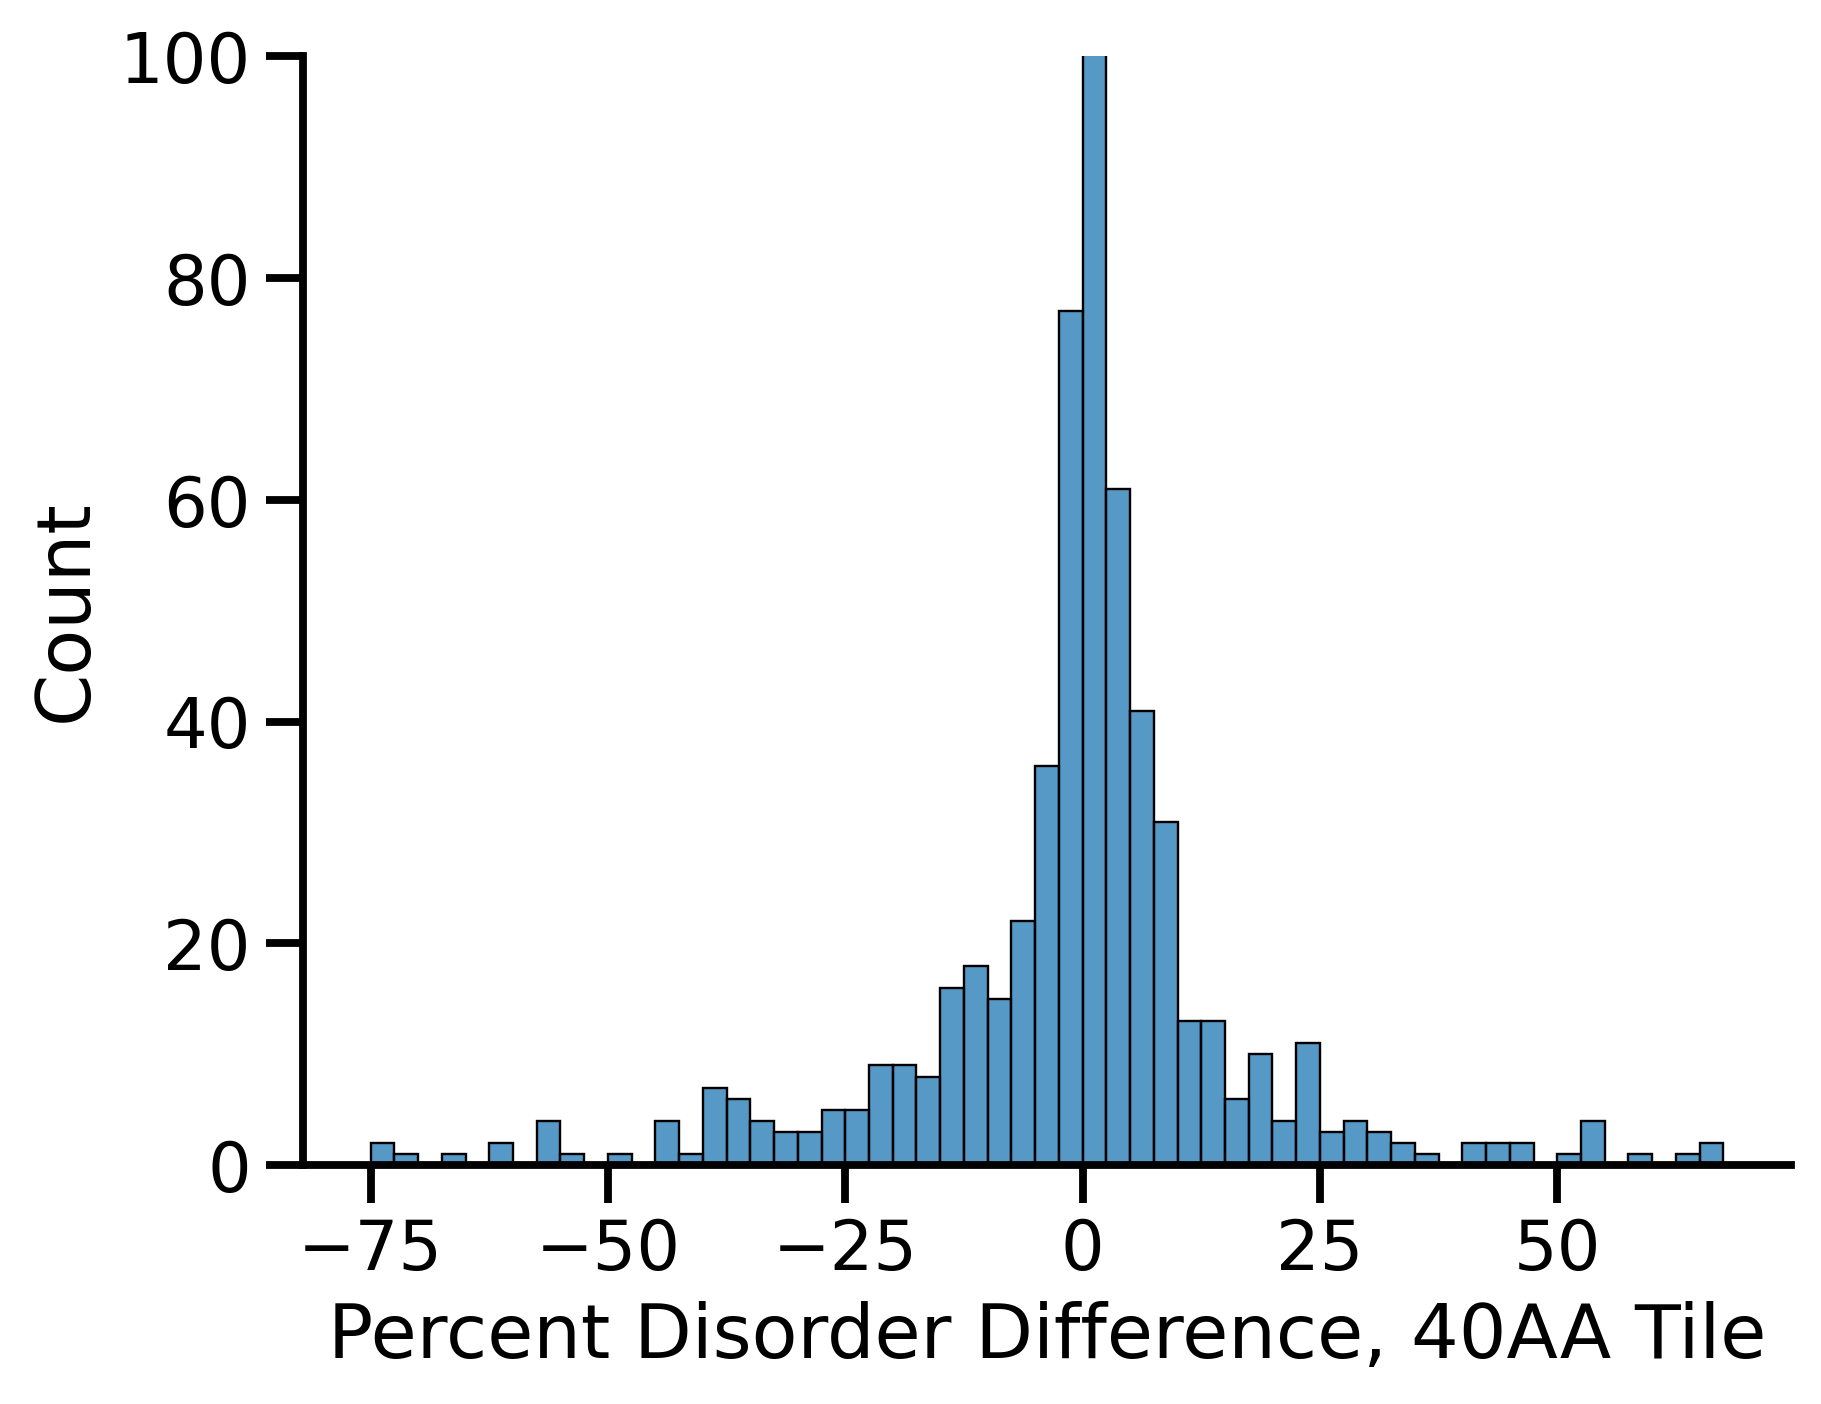

In [66]:
plt.style.use('default')
sns.set_context('talk')
plt.figure(dpi = 300)
sns.histplot(all_AD_df_with_tiles_no_ERG["disord_diff"], bins = np.arange(-75, 70, 2.5))
plt.ylim(0, 100)
sns.despine()
plt.xlabel("Percent Disorder Difference, 40AA Tile")

In [59]:
all_AD_df_with_tiles_no_ERG["abs_disord_diff"] = all_AD_df_with_tiles_no_ERG["disord_diff"].abs()
all_AD_df_with_tiles_no_ERG[all_AD_df_with_tiles_no_ERG["abs_disord_diff"] < 100 * 1/40]

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_60857/1779062465.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_AD_df_with_tiles_no_ERG["abs_disord_diff"] = all_AD_df_with_tiles_no_ERG["disord_diff"].abs()


,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new,var_ProteinSeq,centered_start,centered_end,var_tile,wt_tile,var_tile_disord,wt_tile_disord,disord_diff,abs_disord_diff
0,g.53506627C>T(p.Asp619Asn),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,619,D,N,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,599,639,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTNT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0,0.0
1,g.53506630T>C(p.Thr618Ala),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,618,T,A,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,598,638,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYADT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0,0.0
2,g.53506633A>G(p.Tyr617His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,617,Y,H,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,597,637,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIHTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0,0.0
5,g.53506642G>A(p.Pro614Ser),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,S,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,594,634,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHISSIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0,0.0
6,g.53506645T>C(p.Ile613Val),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,613,I,V,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,593,633,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHVPSIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,100.0,100.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3152,g.49030459G>A(p.Thr476Met),PGAAMFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,476,T,M,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,456,496,DSLKPEQLDIEEEGRPGAAMFHVGGGPAQNAPHQQPPAPP,DSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPAPP,100.0,100.0,0.0,0.0
3153,g.49030465G>A(p.Ala474Val),PGVATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,V,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGVATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA,100.0,100.0,0.0,0.0
3154,g.49030466C>T(p.Ala474Thr),PGTATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,474,A,T,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,454,494,ASDSLKPEQLDIEEEGRPGTATFHVGGGPAQNAPHQQPPA,ASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPPA,100.0,100.0,0.0,0.0
3155,g.49030468C>T(p.Gly473Asp),PDAATFHVGGGPAQNAPHQQPPAPPSDALLDLHFPSDHLGDLGDPF...,TFE3_P19532_AD_472-575,P19532,472,575,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,473,G,D,MSHAAEPARDGVEASAEGPRAVFVLLEERRPADSAQLLSLNSLLPE...,453,493,SASDSLKPEQLDIEEEGRPDAATFHVGGGPAQNAPHQQPP,SASDSLKPEQLDIEEEGRPGAATFHVGGGPAQNAPHQQPP,100.0,100.0,0.0,0.0


In [61]:
len(all_AD_df_with_tiles_no_ERG[all_AD_df_with_tiles_no_ERG["abs_disord_diff"] < 100 * 1/40]) / len(all_AD_df_with_tiles_no_ERG)

0.8434278350515464

In [31]:
all_AD_df_with_tiles_no_ERG["abs_disord_diff"] = all_AD_df_with_tiles_no_ERG["disord_diff"].abs()
all_AD_df_with_tiles_no_ERG[all_AD_df_with_tiles_no_ERG["abs_disord_diff"] > 25]

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_60857/3924557667.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_AD_df_with_tiles_no_ERG["abs_disord_diff"] = all_AD_df_with_tiles_no_ERG["disord_diff"].abs()


,key,seq,name,uniprotID,start,end,ProteinSeq,var_pos,var_orig,var_new,var_ProteinSeq,centered_start,centered_end,var_tile,wt_tile,var_tile_disord,wt_tile_disord,disord_diff,abs_disord_diff
3,g.53506638G>A(p.Ser615Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,615,S,F,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,595,635,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPFIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,62.5,100.0,-37.5,37.5
4,g.53506641G>A(p.Pro614Leu),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,614,P,L,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,594,634,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHILSIYTDT,ALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIYTDT,60.0,100.0,-40.0,40.0
12,g.53506693C>G(p.Asp597His),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,597,D,H,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,577,617,CPTALPQQPSEDVVSSGPEHCGFFPNGAFDHCLGHIPSIY,CPTALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGHIPSIY,60.0,100.0,-40.0,40.0
15,g.53506707G>A(p.Ser592Phe),AESTRDGLGPGLLSPIVSPLKGLGPPPLPPSSQSHSPGGQPFPTLP...,GLIS1_Q8NBF1_AD_447-620,Q8NBF1,447,620,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,592,S,F,MAEARTSLSAHCRGPLATGLHPDLDLPGRSLATPAPSCYLLGSEPS...,572,612,LAEASCPTALPQQPSEDVVFSGPEDCGFFPNGAFDHCLGH,LAEASCPTALPQQPSEDVVSSGPEDCGFFPNGAFDHCLGH,67.5,100.0,-32.5,32.5
76,g.60502808C>T(p.Val379Met),ELEHLAQNISKSHLETCQYLREELQQITWQTFLQEEIENYQNKQRE...,RORA_P35398_AD_272-385,P35398,272,385,MESAPAAPDPAASEPGSSGADAAAGSRETPLNQESARKSEPPAPVR...,379,V,M,MESAPAAPDPAASEPGSSGADAAAGSRETPLNQESARKSEPPAPVR...,359,399,SLEVVFIRMCRAFDSQNNTMYFDGKYASPDVFKSLGCEDF,SLEVVFIRMCRAFDSQNNTVYFDGKYASPDVFKSLGCEDF,52.5,0.0,52.5,52.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3028,g.26183777C>T(p.Ser276Leu),HLNGTDTSFSLEDLFQLLSSQPENLLEGISLGDIPLPGSISDGMNS...,NFE2L3-NF2L3_Q9Y4A8_AD_252-451,Q9Y4A8,252,451,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,276,S,L,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,256,296,DTSFSLEDLFQLLSSQPENLLEGISLGDIPLPGSISDGMN,DTSFSLEDLFQLLSSQPENSLEGISLGDIPLPGSISDGMN,60.0,100.0,-40.0,40.0
3043,g.26184686G>T(p.Asp330Tyr),HLNGTDTSFSLEDLFQLLSSQPENSLEGISLGDIPLPGSISDGMNS...,NFE2L3-NF2L3_Q9Y4A8_AD_252-451,Q9Y4A8,252,451,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,330,D,Y,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,310,350,QDVNLHEAILLCPNNTFRRYPTARTSQSQEPFLQLNSHTT,QDVNLHEAILLCPNNTFRRDPTARTSQSQEPFLQLNSHTT,50.0,95.0,-45.0,45.0
3044,g.26184690C>T(p.Pro331Leu),HLNGTDTSFSLEDLFQLLSSQPENSLEGISLGDIPLPGSISDGMNS...,NFE2L3-NF2L3_Q9Y4A8_AD_252-451,Q9Y4A8,252,451,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,331,P,L,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,311,351,DVNLHEAILLCPNNTFRRDLTARTSQSQEPFLQLNSHTTN,DVNLHEAILLCPNNTFRRDPTARTSQSQEPFLQLNSHTTN,60.0,87.5,-27.5,27.5
3057,g.26184776A>T(p.Asn360Tyr),HLNGTDTSFSLEDLFQLLSSQPENSLEGISLGDIPLPGSISDGMNS...,NFE2L3-NF2L3_Q9Y4A8_AD_252-451,Q9Y4A8,252,451,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,360,N,Y,MKHLKRWWSAGGGLLHLTLLLSLAGLRVDLDLYLLLPPPTLLQDEL...,340,380,PFLQLNSHTTNPEQTLPGTYLTGFLSPVDNHMRNLTSQDL,PFLQLNSHTTNPEQTLPGTNLTGFLSPVDNHMRNLTSQDL,42.5,100.0,-57.5,57.5


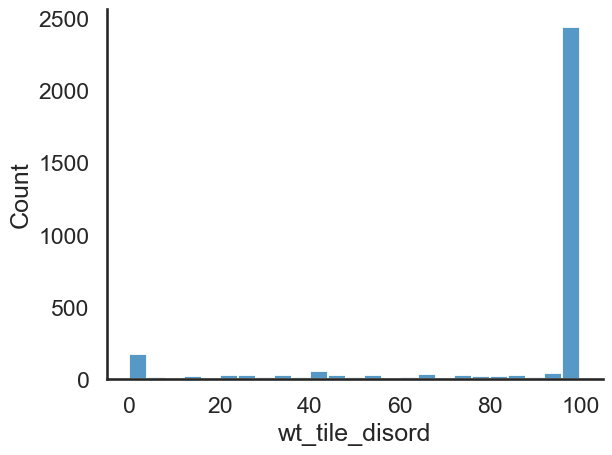

In [32]:
sns.set_context('talk')
sns.set_style('white')
sns.histplot(data =all_AD_df_with_tiles_no_ERG, x = "wt_tile_disord", bins = 25)
sns.despine()

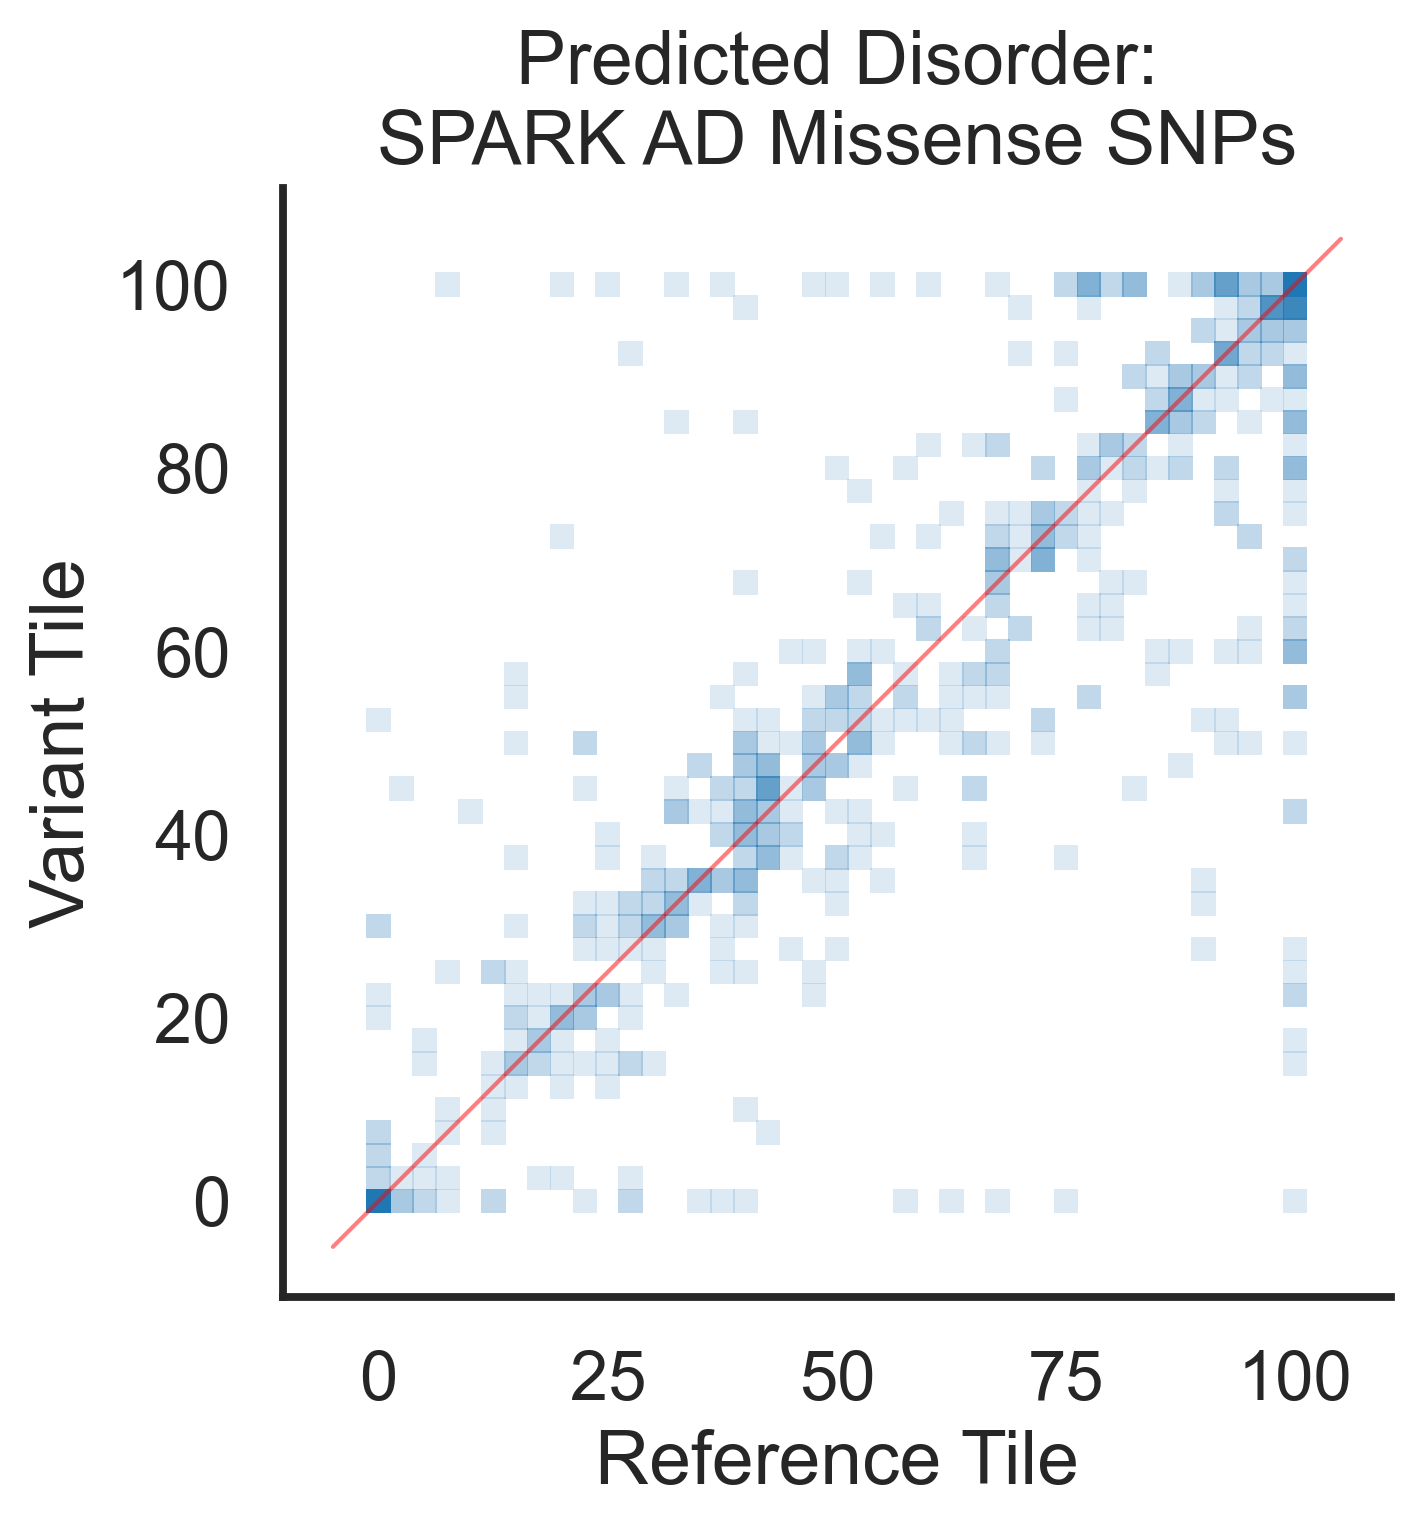

In [33]:
plt.figure(dpi=300)

# Scatterplot
ax = sns.scatterplot(data=all_AD_df_with_tiles_no_ERG, x="wt_tile_disord", y="var_tile_disord", s=35, alpha=0.15, marker='s', edgecolor='none')

# Add y = x line
xlims = ax.get_xlim()
ylims = ax.get_ylim()
ax.plot([min(xlims[0], ylims[0]), max(xlims[1], ylims[1])], 
        [min(xlims[0], ylims[0]), max(xlims[1], ylims[1])], 
        color='red', linestyle='-', linewidth=1, zorder=1, alpha = 0.5)

# Set aspect ratio and remove spines
ax.set_aspect('equal', adjustable='box')
plt.xlabel("Reference Tile")
plt.ylabel("Variant Tile")
plt.title("Predicted Disorder:\nSPARK AD Missense SNPs")
sns.despine()

In [34]:
all_AD_df_with_tiles_no_ERG.sort_values(by = "abs_disord_diff", ascending = False)[["name", "key", "wt_tile_disord", "var_tile_disord", "disord_diff"]].head(20)

,name,key,wt_tile_disord,var_tile_disord,disord_diff
1613,NKX2-2_O95096_AD_220-273,g.21512083T>A(p.Gln221Leu),100.0,0.0,-100.0
2938,ESR2_Q92731_AD_304-500,g.64235012A>G(p.Leu455Pro),7.5,100.0,92.5
805,SRCAP_Q6ZRS2_AD_198-1445,g.30722577C>A(p.Leu1241Ile),100.0,15.0,-85.0
1982,DLX3_O60479_AD_2-91,g.49994772C>A(p.Gly76Val),100.0,17.5,-82.5
2039,NR1D1_P20393_AD_8-285,g.40096040C>G(p.Ala218Pro),20.0,100.0,80.0
804,SRCAP_Q6ZRS2_AD_198-1445,g.30722577C>T(p.Leu1241Phe),100.0,22.5,-77.5
1020,MSX2_P35548_AD_234-267,g.174729537G>T(p.Gly253Val),100.0,22.5,-77.5
665,SRCAP_Q6ZRS2_AD_198-1445,g.30716132G>C(p.Glu854Gln),25.0,100.0,75.0
2331,HIVEP3_Q5T1R4_AD_211-1074,g.41582750G>A(p.Pro683Leu),75.0,0.0,-75.0
2896,ESR2_Q92731_AD_1-148,g.64282712G>A(p.His92Tyr),100.0,25.0,-75.0


In [43]:
res_disor_change = all_AD_df_with_tiles_no_ERG[["var_orig", "var_new", "disord_diff"]]
res_disor_change

,var_orig,var_new,disord_diff
0,D,N,0.0
1,T,A,0.0
2,Y,H,0.0
3,S,F,-37.5
4,P,L,-40.0
...,...,...,...
3152,T,M,0.0
3153,A,V,0.0
3154,A,T,0.0
3155,G,D,0.0


In [36]:
to_var = res_disor_change.drop(columns = "var_orig").groupby("var_new").mean().sort_values(by = "disord_diff", ascending = False)
to_var

,disord_diff
var_new,
P,2.435897
G,1.375839
S,1.093294
D,0.882353
M,0.794118
E,0.563725
T,0.344828
N,0.292793
Q,0.239726


In [37]:
from_var = res_disor_change.drop(columns = "var_new").groupby("var_orig").mean().sort_values(by = "disord_diff", ascending = False)
from_var

,disord_diff
var_orig,
W,3.125000
I,2.475000
F,1.458333
K,1.418919
A,0.891473
E,0.873494
V,0.862069
Y,0.613208
L,0.402098


Text(0.5, 0, 'Reference AA')

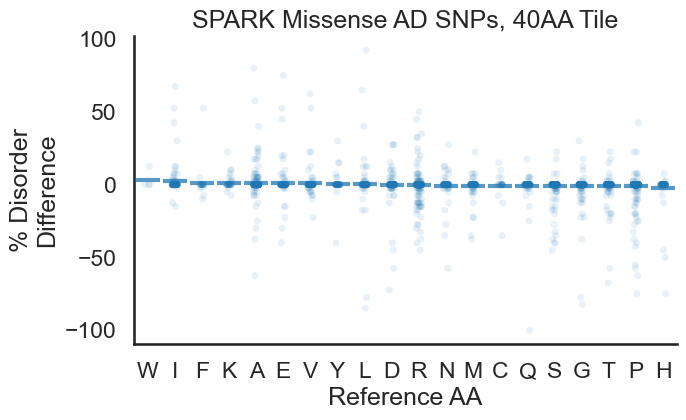

In [38]:
plt.figure(figsize = (7, 4))
sns.stripplot(data = res_disor_change, x = "var_orig", y = "disord_diff", s = 5, alpha = 0.1, edgecolor = 'none', order =from_var.index, zorder = 5, dodge=True)
sns.pointplot(data=res_disor_change, x="var_orig", y="disord_diff", linestyle = 'none', markers="_",  errorbar=None, zorder = 10, markersize = 17, markeredgewidth = 3, alpha = 0.75)
sns.despine()
plt.title("SPARK Missense AD SNPs, 40AA Tile");
plt.ylabel("% Disorder\nDifference")
plt.xlabel("Reference AA")

Text(0.5, 0, 'Variant AA')

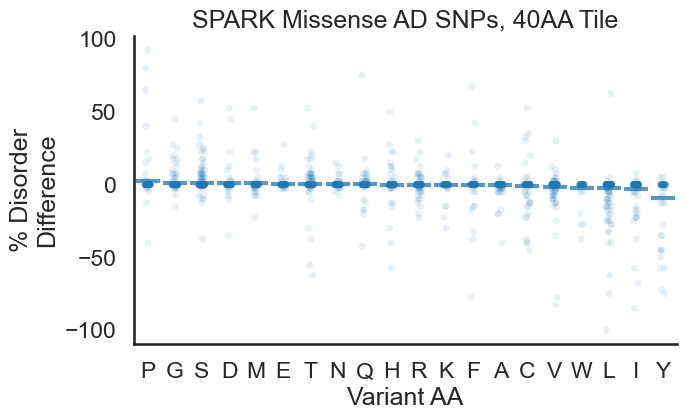

In [39]:
plt.figure(figsize = (7, 4))
sns.stripplot(data = res_disor_change, x = "var_new", y = "disord_diff", s = 5, alpha = 0.1, edgecolor = 'none', order =to_var.index, zorder = 5, dodge=True)
sns.pointplot(data=res_disor_change, x="var_new", y="disord_diff", linestyle = 'none', markers="_",  errorbar=None, zorder = 10, markersize = 17, markeredgewidth = 3, alpha = 0.75)
sns.despine()
plt.title("SPARK Missense AD SNPs, 40AA Tile")
plt.ylabel("% Disorder\nDifference")
plt.xlabel("Variant AA")

Text(0.5, 1.05, 'SPARK Missense AD SNPs, 40AA Tile')

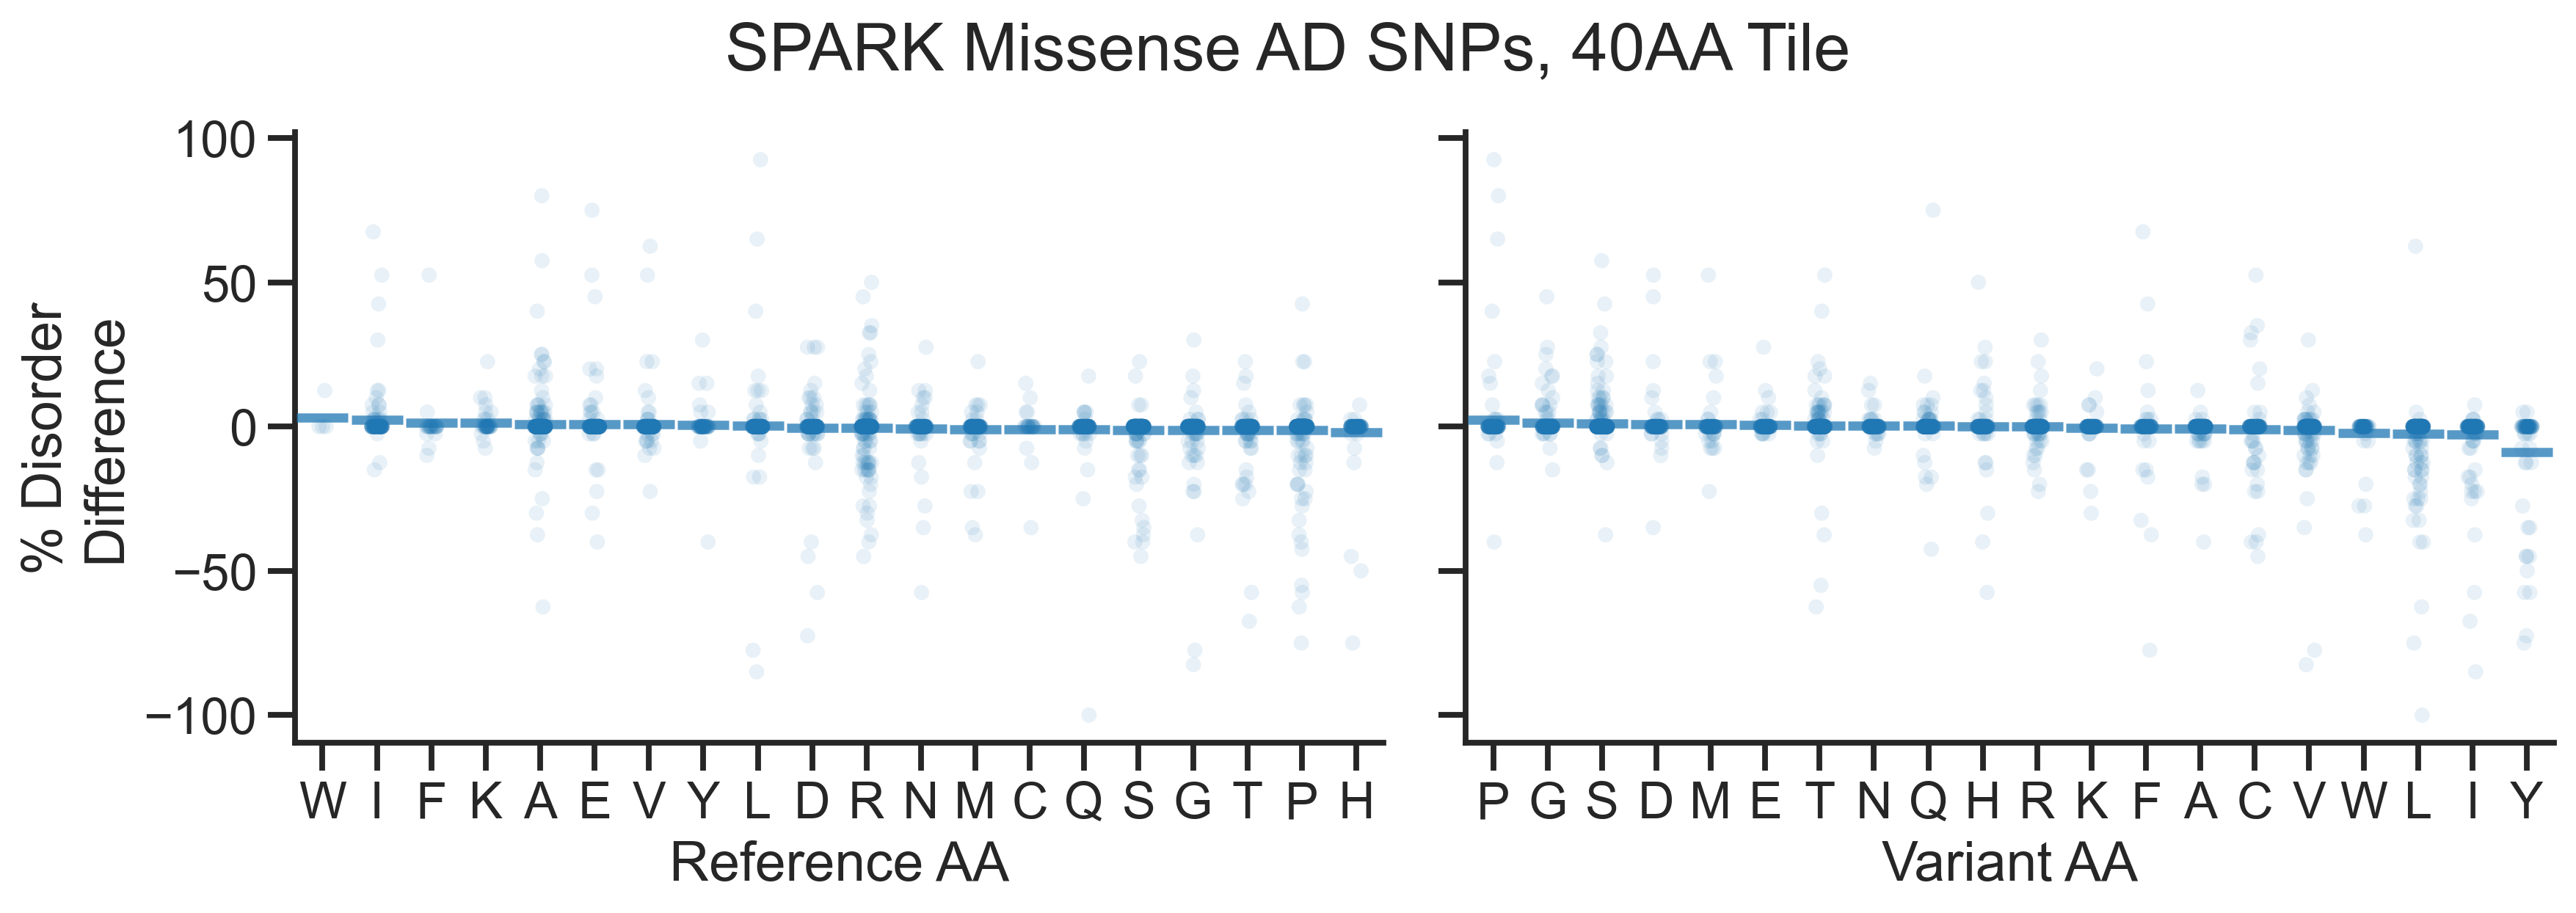

In [40]:
sns.set_style('ticks')

fig, axs = plt.subplots(1, 2, sharey = True, figsize = (12,4), dpi = 300)
sns.stripplot(data = res_disor_change, x = "var_orig", y = "disord_diff", s = 5, alpha = 0.1, edgecolor = 'none', order =from_var.index, zorder = 5, dodge=True, ax = axs[0])
sns.pointplot(data=res_disor_change, x="var_orig", y="disord_diff", linestyle = 'none', markers="_",  errorbar=None, zorder = 10, markersize = 17, markeredgewidth = 3, alpha = 0.75, ax = axs[0])
axs[0].set_xlabel("Reference AA")

sns.stripplot(data = res_disor_change, x = "var_new", y = "disord_diff", s = 5, alpha = 0.1, edgecolor = 'none', order =to_var.index, zorder = 5, dodge=True, ax = axs[1])
sns.pointplot(data=res_disor_change, x="var_new", y="disord_diff", linestyle = 'none', markers="_",  errorbar=None, zorder = 10, markersize = 17, markeredgewidth = 3, alpha = 0.75, ax = axs[1])
axs[1].set_xlabel("Variant AA")

axs[0].set_ylabel("% Disorder\nDifference")
sns.despine()
plt.tight_layout(pad = 1)
plt.suptitle("SPARK Missense AD SNPs, 40AA Tile", y = 1.05)


In [41]:
agg_disord_change = res_disor_change.groupby(["var_orig", "var_new"]).agg([np.mean, np.std, np.count_nonzero])
agg_disord_change.columns = ['_'.join(col).strip() for col in agg_disord_change.columns]
agg_disord_change = agg_disord_change.reset_index()
agg_disord_change = agg_disord_change.sort_values(by = ["var_orig", "var_new"])
agg_disord_change

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_60857/1338192145.py:1: FutureWarning: The provided callable <function mean at 0x104029e40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_disord_change = res_disor_change.groupby(["var_orig", "var_new"]).agg([np.mean, np.std, np.count_nonzero])
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_60857/1338192145.py:1: FutureWarning: The provided callable <function std at 0x104029f80> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_disord_change = res_disor_change.groupby(["var_orig", "var_new"]).agg([np.mean, np.std, np.count_nonzero])


,var_orig,var_new,disord_diff_mean,disord_diff_std,disord_diff_count_nonzero
0,A,D,2.777778,7.441905,2
1,A,E,0.000000,0.000000,0
2,A,G,0.119048,0.545545,1
3,A,P,4.250000,17.846200,3
4,A,S,5.065789,11.500394,13
...,...,...,...,...,...
139,Y,D,0.000000,NaN,0
140,Y,F,0.000000,3.535534,2
141,Y,H,2.045455,4.850023,2
142,Y,N,0.000000,0.000000,0


<Figure size 1920x1440 with 0 Axes>

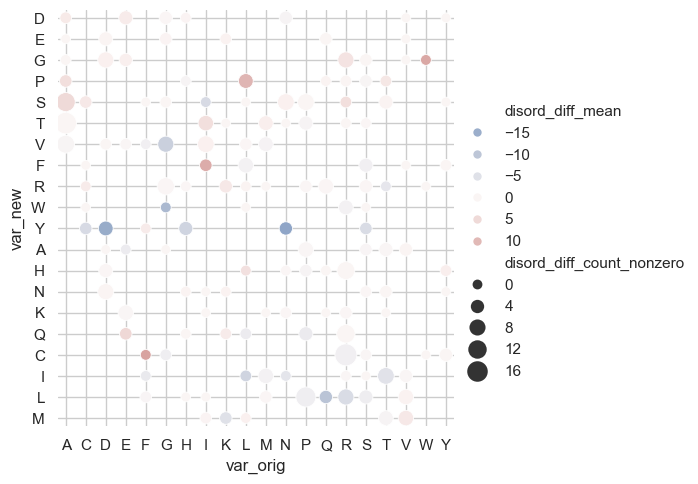

In [42]:
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(dpi = 300)

# Draw each cell as a scatter point with varying size and color
g = sns.relplot(
    data=agg_disord_change,
    x="var_orig", y="var_new", hue="disord_diff_mean", size="disord_diff_count_nonzero", palette = "vlag", hue_norm = (-30, 30), sizes = (50, 250)
    # palette="vlag", hue_norm=(-1, 1), edgecolor=".7",
    # height=10, sizes=(50, 250), size_norm=(-.2, .8),
)

# # Tweak the figure to finalize
# g.set(xlabel="", ylabel="", aspect="equal")
g.despine(left=True, bottom=True)
g.ax.margins(.02)
# for label in g.ax.get_xticklabels():
#     label.set_rotation(90)